<a href="https://colab.research.google.com/github/alicedambroz/Preferential-Flow/blob/main/Preferential_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Run first

In [1]:
!pip install PyWavelets

# 1. Mount Drive (for saving plots later)
from google.colab import drive
drive.mount('/content/drive')

# 2. Authenticate and Import Libraries
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np
import pywt

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

Mounted at /content/drive


#Call data

In [2]:
df_p_file_path = '/content/drive/MyDrive/Preferential-Flow/Cleaned_Data/df_p_cleaned.csv'
df_p = pd.read_csv(df_p_file_path)

df_m_file_path = '/content/drive/MyDrive/Preferential-Flow/Cleaned_Data/df_m_cleaned.csv'
df_m = pd.read_csv(df_m_file_path)

file_path = '/content/drive/MyDrive/Preferential-Flow/Individual_Events/Nonsequential_Flow_Summary.csv'
df_flow_summary = pd.read_csv(file_path)

In [ ]:
import os
import pandas as pd
from google.colab import drive, auth
from google.auth import default
import gspread

# ---------------------------------------------------------
# 1. SETUP PATHS & DRIVE MOUNT
# ---------------------------------------------------------
drive.mount('/content/drive', force_remount=False)

save_dir = '/content/drive/MyDrive/Preferential-Flow/Cleaned_Data'
os.makedirs(save_dir, exist_ok=True)

path_m = os.path.join(save_dir, 'df_m_cleaned.csv')
path_p = os.path.join(save_dir, 'df_p_cleaned.csv')

# ---------------------------------------------------------
# 2. CHECK IF CLEANED FILES ALREADY EXIST ON DRIVE
# ---------------------------------------------------------
if os.path.exists(path_m) and os.path.exists(path_p):
    print("⚡ Cleaned data found on Google Drive! Loading cached files...")
    df_m = pd.read_csv(path_m, parse_dates=['Date'])
    df_p = pd.read_csv(path_p, parse_dates=['Date'])

    # Ensure site identifiers remain strings
    for df in [df_m, df_p]:
        df['Site'] = df['Site'].astype(str)

    print("✅ Cached datasets loaded successfully!")

else:
    print("🌐 Cleaned files not found locally. Fetching fresh data from Google Sheets...")

    # 1. Authenticate
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # 2. Sheet Configurations
    moisture_sheet_id = '1X0SsYtIwMhnquihj4gKsdeDaX0D6Ljbsvvwhc5bU3ew'
    precip_sheet_id = '1NvZ1li6_cxliYUEANrEAGRlA3gGdgWhCxVX_J9ZrspQ'

    print("Fetching Moisture and Precipitation tabs...")
    m_rows = gc.open_by_key(moisture_sheet_id).worksheet('Moisture').get_all_values()
    df_m = pd.DataFrame.from_records(m_rows[1:], columns=m_rows[0])

    p_rows = gc.open_by_key(precip_sheet_id).worksheet('Precipitation').get_all_values()
    df_p = pd.DataFrame.from_records(p_rows[1:], columns=p_rows[0])

    # 3. Deterministic Anonymization (Mapping Table)
    all_farms = pd.concat([df_m['F_name'], df_p['F_name']]).dropna().unique()
    all_farms_sorted = sorted(all_farms)
    farm_mapping = {farm: f"Farm_{i+1}" for i, farm in enumerate(all_farms_sorted)}

    # Map Anon_Farm_ID while preserving F_name
    df_m['Anon_Farm_ID'] = df_m['F_name'].map(farm_mapping)
    df_p['Anon_Farm_ID'] = df_p['F_name'].map(farm_mapping)

    # 4. Clean Moisture Data
    df_m['Date'] = pd.to_datetime(df_m['Date'], errors='coerce')
    moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']
    for col in moisture_cols:
        df_m[col] = pd.to_numeric(df_m[col], errors='coerce')

    df_m = df_m.dropna(subset=['Date'])

    # Aggregate duplicate timestamps cleanly
    compound_key = ['F_name', 'Anon_Farm_ID', 'State', 'Site', 'Management', 'Date']
    df_m = df_m.groupby(compound_key, as_index=False)[moisture_cols].mean()

    # Re-build Unit IDs
    df_m['Site'] = df_m['Site'].astype(str)
    df_m['Unit_ID'] = (
        df_m['F_name'].astype(str) + "_" +
        df_m['State'].astype(str) + "_Site-" +
        df_m['Site'] + "_" +
        df_m['Management'].astype(str)
    )

    # 5. Clean Precipitation Data
    df_p['Date'] = pd.to_datetime(df_p['Date'], errors='coerce')
    df_p['Rainfall_mm'] = pd.to_numeric(df_p['Rainfall_mm'], errors='coerce')
    df_p = df_p.dropna(subset=['Date', 'Rainfall_mm'])
    df_p['Site'] = df_p['Site'].astype(str)

    # 6. Save Cleaned Data to Google Drive
    df_m.to_csv(path_m, index=False)
    df_p.to_csv(path_p, index=False)

    print(f"💾 Cleaned datasets saved to Google Drive at:\n - {path_m}\n - {path_p}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🌐 Cleaned files not found locally. Fetching fresh data from Google Sheets...
Fetching Moisture and Precipitation tabs...
💾 Cleaned datasets saved to Google Drive at:
 - /content/drive/MyDrive/Preferential-Flow/Cleaned_Data/df_m_cleaned.csv
 - /content/drive/MyDrive/Preferential-Flow/Cleaned_Data/df_p_cleaned.csv


#Check moisture data and search for duplicates

In [ ]:
# Open the sheet using the provided ID
sheet_id = '1X0SsYtIwMhnquihj4gKsdeDaX0D6Ljbsvvwhc5bU3ew'
worksheet = gc.open_by_key(sheet_id).worksheet('Moisture')

# Fetch all data and convert to a Pandas DataFrame
rows = worksheet.get_all_values()
df = pd.DataFrame.from_records(rows[1:], columns=rows[0])

# 3. Preprocess the Data
print("Converting dates and cleaning data...")

# Let pandas automatically infer the date format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define the updated moisture columns
moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']

# Convert all moisture columns to numeric
for col in moisture_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where Date is missing
df = df.dropna(subset=['Date'])

# ---------------------------------------------------------
# NEW: The "Compound Key" for true unique locations
# ---------------------------------------------------------
# A single unique sensor reading is defined by ALL of these columns combined
unique_identifiers = ['F_name', 'State', 'Site', 'Management', 'Date']

# Find all rows where this specific combination appears more than once
duplicates = df[df.duplicated(subset=unique_identifiers, keep=False)]

# Sort them so the conflicting rows appear right next to each other
duplicates = duplicates.sort_values(by=unique_identifiers)

print(f"Total true duplicate rows found: {len(duplicates)}\n")

if len(duplicates) > 0:
    print("Here is a sample of the true duplicate entries:")
    # Display all the identifier columns so you can verify the distinct units
    cols_to_show = ['F_name', 'State', 'Site', 'Management', 'Date', '10_M', '20_M']
    print(duplicates[cols_to_show].tail(50))
else:
    print("No duplicates found! The previous 'duplicates' were definitely just the different locations and management types overlapping.")

Converting dates and cleaning data...
Total true duplicate rows found: 855

Here is a sample of the true duplicate entries:
             F_name State      Site Management                Date  10_M  20_M
139663  Schlichting    MN    Benton         SH 2022-09-27 10:43:00  0.12  0.11
139664  Schlichting    MN    Benton         SH 2022-09-27 10:43:00  0.12  0.11
139665  Schlichting    MN    Benton         SH 2022-09-27 10:44:00  0.12  0.11
139666  Schlichting    MN    Benton         SH 2022-09-27 10:44:00  0.12  0.11
139667  Schlichting    MN    Benton         SH 2022-09-27 10:45:00  0.12  0.11
139668  Schlichting    MN    Benton         SH 2022-09-27 10:45:00  0.12  0.11
139669  Schlichting    MN    Benton         SH 2022-09-27 10:46:00  0.12  0.11
139670  Schlichting    MN    Benton         SH 2022-09-27 10:46:00  0.12  0.11
139671  Schlichting    MN    Benton         SH 2022-09-27 10:46:00  0.12  0.11
139674  Schlichting    MN    Benton         SH 2022-09-27 10:49:00  0.12  0.11
139675 

In [ ]:
duplicates

,F_name,State,Site,Management,Texture,Date,10_M,20_M,40_M,60_M,80_M,100_M
13211,Angell,MN,Mower,SH,medium,2023-07-18 14:00:00,0.15,0.14,0.24,0.27,0.33,0.34
13212,Angell,MN,Mower,SH,medium,2023-07-18 14:00:00,0.17,0.20,0.26,0.27,0.28,0.30
34408,Boots,MN,Redwood,CV,moderately fine,2021-08-23 16:36:00,0.20,0.23,0.31,0.38,0.35,0.35
34409,Boots,MN,Redwood,CV,moderately fine,2021-08-23 16:36:00,0.20,0.25,0.34,0.39,0.37,0.35
49523,C.Cotter,MN,Mower,CV,medium,2021-08-23 16:36:00,0.22,0.18,0.28,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
388711,Vanpelt,MN,Freeborn,CV,medium,2023-08-09 19:30:00,0.13,0.27,0.29,0.29,0.29,0.23
407930,W.Pfarr,MN,Redwood,CV,medium,2021-08-23 16:36:00,0.13,0.30,0.35,0.37,0.36,0.35
407931,W.Pfarr,MN,Redwood,CV,medium,2021-08-23 16:36:00,-0.01,0.24,0.32,0.34,0.33,0.35
445270,Zimmerman,WI,Dodge,CV,medium,2023-05-30 18:36:00,0.13,0.36,0.42,0.45,0.35,0.35


#Plot data

In [ ]:
# Assuming 'df' is already loaded via worksheet.get_all_values()

print("Converting dates and cleaning data...")
# FIX 1: Let pandas automatically infer the format so we don't drop rogue rows
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define the moisture columns
moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']

for col in moisture_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Date'])

# ---------------------------------------------------------
# 1. RESOLVE TRUE DUPLICATES
# ---------------------------------------------------------
print("Averaging the true duplicate timestamps...")
compound_key = ['F_name', 'State', 'Site', 'Management', 'Date']
agg_funcs = {col: 'mean' for col in moisture_cols}

df = df.groupby(compound_key).agg(agg_funcs).reset_index()

# ---------------------------------------------------------
# 2. CREATE UNIQUE UNIT IDENTIFIER
# ---------------------------------------------------------
# FIX 2: Add .astype(str) to everything to prevent blanks from destroying the ID
df['Unit_ID'] = df['F_name'].astype(str) + "_" + \
                df['State'].astype(str) + "_Site-" + \
                df['Site'].astype(str) + "_" + \
                df['Management'].astype(str)

# Sort chronologically
df = df.sort_values(by=['Unit_ID', 'Date'])

# 3. Prepare Output Directory
output_dir = '/content/drive/My Drive/Preferential-Flow/Full_Period_Plots'
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# 4. GENERATE PLOTS PER UNIQUE UNIT
# ---------------------------------------------------------
unique_units = df['Unit_ID'].unique()
print(f"Found {len(unique_units)} distinct units. Generating plots...")

plots_generated = 0

for unit in unique_units:
    unit_data = df[df['Unit_ID'] == unit]

    # Extract clean metadata for the graph title
    f_name = unit_data['F_name'].iloc[0]
    state = unit_data['State'].iloc[0]
    site = unit_data['Site'].iloc[0]
    mgmt = unit_data['Management'].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 6))

    for col in moisture_cols:
        ax.plot(unit_data['Date'], unit_data[col], label=f'{col.replace("_M", "m")} Depth', linewidth=1.5)

    # Formatting the plot
    ax.set_title(f'Soil Moisture Time Series\n{f_name}, {state} | Site: {site} | Management: {mgmt}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Soil Moisture', fontsize=12)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)

    ax.legend(title='Sensor Depths', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    # Save the plot
    output_path = os.path.join(output_dir, f'{unit}_moisture_plot.png')
    plt.savefig(output_path, dpi=300)

    plt.close(fig)

    plots_generated += 1
    print(f"Saved: {unit}_moisture_plot.png")

print(f"Analysis complete! Successfully generated {plots_generated} uniquely identified plots.")

Converting dates and cleaning data...
Averaging the true duplicate timestamps...
Found 30 distinct units. Generating plots...
Saved: Angell_MN_Site-Mower_SH_moisture_plot.png
Saved: B.Pfarr_MN_Site-Redwood_SH_moisture_plot.png
Saved: Boots_MN_Site-Redwood_CV_moisture_plot.png
Saved: C.Cotter_MN_Site-Mower_CV_moisture_plot.png
Saved: Conley_WI_Site-Dodge_SH_moisture_plot.png
Saved: Eggert_WI_Site-Dodge_CV_moisture_plot.png
Saved: Griel_WI_Site-Racine_CV_moisture_plot.png
Saved: Gunderson_WI_Site-Racine_SH_moisture_plot.png
Saved: Hammer_WI_Site-Dodge_SH_moisture_plot.png
Saved: Lawler_MN_Site-Olmsted_SH_moisture_plot.png
Saved: Lightly_MN_Site-Freeborn_SH_moisture_plot.png
Saved: McCoy_WI_Site-Dodge_CV_moisture_plot.png
Saved: Neu_WI_Site-Dodge_CV_moisture_plot.png
Saved: Noble_WI_Site-Racine_CV_moisture_plot.png
Saved: Ouderkirk_MN_Site-Mower_CV_moisture_plot.png
Saved: Peirick_WI_Site-Dodge_SH_moisture_plot.png
Saved: Pyfferoen_MN_Site-Dodge_SH_moisture_plot.png
Saved: Roche_WI_Site-D

In [ ]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449247 entries, 0 to 449246
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   F_name        449247 non-null  object        
 1   State         449247 non-null  object        
 2   Site          449247 non-null  object        
 3   Management    449247 non-null  object        
 4   Date          449247 non-null  datetime64[ns]
 5   10_M          449247 non-null  float64       
 6   20_M          449247 non-null  float64       
 7   40_M          440696 non-null  float64       
 8   60_M          424060 non-null  float64       
 9   80_M          413864 non-null  float64       
 10  100_M         412210 non-null  float64       
 11  Anon_Farm_ID  449247 non-null  object        
 12  Unit_ID       449247 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(6)
memory usage: 44.6+ MB


#Plot monthly data

In [ ]:
# 1. Create a 'YearMonth' column to group the data for plotting
# (Assuming 'df' already has our 'Unit_ID' from the previous cell)
df['YearMonth'] = df['Date'].dt.to_period('M')

# Sort chronologically by unit, then date
df = df.sort_values(by=['Unit_ID', 'Date'])

# 2. Prepare Output Directory (Let's make a dedicated folder for these!)
output_dir = '/content/drive/My Drive/Preferential-Flow/Monthly_Plots'
os.makedirs(output_dir, exist_ok=True)

# 3. Generate and Save Monthly Plots for Each Unit
unique_units = df['Unit_ID'].unique()
print(f"Found {len(unique_units)} distinct units. Generating monthly plots...")

plots_generated = 0

for unit in unique_units:
    # Filter data for this specific location + management combo
    unit_data = df[df['Unit_ID'] == unit]

    # Extract clean metadata for the graph title
    f_name = unit_data['F_name'].iloc[0]
    state = unit_data['State'].iloc[0]
    site = unit_data['Site'].iloc[0]
    mgmt = unit_data['Management'].iloc[0]

    # Get the unique months for this specific unit
    unique_months = unit_data['YearMonth'].unique()

    for month in unique_months:
        # Filter data for this specific month
        month_data = unit_data[unit_data['YearMonth'] == month]

        # Skip this month if ALL moisture data is missing (NaN)
        if month_data[moisture_cols].isna().all().all():
            continue

        # Create the plot
        fig, ax = plt.subplots(figsize=(14, 6))

        for col in moisture_cols:
            ax.plot(month_data['Date'], month_data[col], label=f'{col.replace("_M", "m")} Depth', linewidth=1.5)

        # Formatting the plot with our new compound title
        ax.set_title(f'Soil Moisture Time Series\n{f_name}, {state} | Site: {site} | Management: {mgmt} ({month})', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Soil Moisture', fontsize=12)

        # Format the x-axis to look nice for a single month
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
        plt.xticks(rotation=0)

        # Add a legend outside the plot area
        ax.legend(title='Sensor Depths', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()

        # Save the plot to your Google Drive folder
        safe_month_str = str(month)
        output_path = os.path.join(output_dir, f'{unit}_{safe_month_str}_moisture_plot.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')

        # Close the plot to save memory in Colab
        plt.close(fig)
        plots_generated += 1

        print(f"Saved: {unit}_{safe_month_str}_moisture_plot.png")

print(f"Analysis complete! Successfully generated {plots_generated} monthly plots.")

Found 30 distinct units. Generating monthly plots...
Saved: Angell_MN_Site-Mower_SH_2021-07_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2021-08_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2021-09_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2022-05_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2022-06_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2022-07_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2022-08_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2022-09_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2023-05_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2023-06_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2023-07_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2023-08_moisture_plot.png
Saved: Angell_MN_Site-Mower_SH_2023-09_moisture_plot.png
Saved: B.Pfarr_MN_Site-Redwood_SH_2021-07_moisture_plot.png
Saved: B.Pfarr_MN_Site-Redwood_SH_2021-08_moisture_plot.png
Saved: B.Pfarr_MN_Site-Redwood_SH_2021-09_moisture_plot.png
Saved: B.Pfarr_MN_Site-Red

#Plots of moisture based on daily precipitation >25 mm
##With anonymous farm ID

In [ ]:
rain_threshold = 25.0

# Filter for heavy rain
heavy_rain = df_p[df_p['Rainfall_mm'] >= rain_threshold].copy()

# ---------------------------------------------------------
# 2. PLOTTING SETUP
# ---------------------------------------------------------
output_dir = '/content/drive/My Drive/Preferential-Flow/Individual_Events'
os.makedirs(output_dir, exist_ok=True)

print(f"Found {len(heavy_rain)} qualifying rain events. Generating individual plots...")
plots_generated = 0

for index, event in heavy_rain.iterrows():
    # Pull metadata directly from the precipitation row
    f_name = event['F_name']
    state = event['State']
    site_num = str(event['Site'])
    rain_date = event['Date']
    precip_amount = event['Rainfall_mm']

    # Reconstruct the Base Site ID to find matching moisture data
    base_site = f"{f_name}_{state}_Site-{site_num}"

    window_start = rain_date - pd.Timedelta(hours=48)
    window_end = rain_date + pd.Timedelta(hours=72)

    # Isolate ALL moisture data for this specific physical location and time window
    mask = (df_m['Base_Site_ID'] == base_site) & (df_m['Date'] >= window_start) & (df_m['Date'] <= window_end)
    site_event_data = df_m[mask].copy()

    # Skip if there's no moisture data at all for this storm
    if site_event_data.empty or site_event_data[moisture_cols].isna().all().all():
        continue

    # Identify which management types actually exist at this site during this storm
    available_managements = site_event_data['Management'].unique()

    # Create a separate plot for EVERY management type found
    for mgmt in available_managements:
        unit_data = site_event_data[site_event_data['Management'] == mgmt].copy()

        # Calculate Change in Moisture (Delta) for this specific unit
        for col in moisture_cols:
            baseline = unit_data[col].dropna().iloc[0] if not unit_data[col].dropna().empty else 0
            unit_data.loc[:, col] = unit_data[col] - baseline

        # --- Plotting ---
        fig, ax1 = plt.subplots(figsize=(12, 6))

        for col in moisture_cols:
            ax1.plot(unit_data['Date'], unit_data[col], label=f'{col.replace("_M", "m")} Depth', linewidth=2)

        # Formatting the primary axis (Moisture)
        ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Change in Soil Moisture ($\Delta \Theta$)', fontsize=12, fontweight='bold')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))

        # Create a secondary y-axis for the Precipitation
        ax2 = ax1.twinx()
        ax2.bar(rain_date, precip_amount, width=1, align='edge', color='#1f77b4', alpha=0.3, label='Precip (mm)')
        ax2.set_ylabel('Daily Precipitation (mm)', fontsize=12, color='#1f77b4', fontweight='bold')
        ax2.invert_yaxis()
        ax2.set_ylim(precip_amount * 3, 0)

        # Add the Shaded Event Window background
        ax1.axvspan(rain_date, rain_date + pd.Timedelta(days=1), color='gray', alpha=0.15, label='Rain Event Day')

        # Titles and Legends with full metadata!
        date_str = rain_date.strftime('%Y-%m-%d')
        clean_site = site_num if "Site" in site_num else f"Site {site_num}"

        plt.title(f'Event Window: {f_name}, {state} | {clean_site} | Management: {mgmt}\nRainfall: {precip_amount}mm on {date_str}', fontsize=14, fontweight='bold')

        # Combine legends from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, bbox_to_anchor=(1.05, 1), loc='upper left')

        ax1.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()

        # Save the plot using the full Unit_ID
        unit_id_str = f"{base_site}_{mgmt}"
        output_path = os.path.join(output_dir, f'{unit_id_str}_Event_{date_str}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()

        plots_generated += 1

print(f"Analysis complete! Successfully generated {plots_generated} uniquely identified event plots.")

<>:112: SyntaxWarning: invalid escape sequence '\D'
<>:112: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1109/2482818179.py:112: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('Change in Soil Moisture ($\Delta \Theta$)', fontsize=12, fontweight='bold')


Fetching data from Google Sheets...
Anonymizing Farm names...
Cleaning and formatting data...
Found 863 qualifying rain events. Generating individual plots...
Analysis complete! Successfully generated 776 uniquely identified event plots.


##Key for Farm name and numbers

In [ ]:
# ---------------------------------------------------------
# SAVE TO GOOGLE DRIVE
# ---------------------------------------------------------
# Using 'MyDrive' (no space) to avoid the phantom folder trap!
output_dir = '/content/drive/MyDrive/Preferential-Flow'
os.makedirs(output_dir, exist_ok=True)

# Create a clear file name for this specific analysis
output_file = os.path.join(output_dir, 'Key_Farm_ID.csv')

# Save the DataFrame to CSV (index=False prevents it from saving the row numbers)
df_p.to_csv(output_file, index=False)

print(f"💾 Success! The key has been saved to your Drive at: {output_file}")

💾 Success! The flow summary has been saved to your Drive at: /content/drive/MyDrive/Preferential-Flow/Key_Farm_ID.csv


#Plots of moisture based on daily precipitation >25mm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Ensure moisture_cols is defined for the loop
moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']

# Use your specified threshold
rain_threshold = 25.0

# Filter for heavy rain
heavy_rain = df_p[df_p['Rainfall_mm'] >= rain_threshold].copy()

# ---------------------------------------------------------
# 2. PLOTTING SETUP
# ---------------------------------------------------------
# FIXED: Removed the space in 'MyDrive'
output_dir = '/content/drive/MyDrive/Preferential-Flow/Individual_Events'
os.makedirs(output_dir, exist_ok=True)

print(f"Found {len(heavy_rain)} qualifying rain events. Generating individual plots...")
plots_generated = 0

for index, event in heavy_rain.iterrows():
    # Pull metadata directly from the precipitation row
    f_name = event['F_name'] # Using the actual Farm Name!
    state = event['State']
    site_num = str(event['Site'])
    rain_date = event['Date']
    precip_amount = event['Rainfall_mm']

    window_start = rain_date - pd.Timedelta(hours=48)
    window_end = rain_date + pd.Timedelta(hours=72)

    # FIXED: Isolate moisture data using existing columns instead of 'Base_Site_ID'
    mask = (
        (df_m['F_name'] == f_name) &
        (df_m['State'] == state) &
        (df_m['Site'].astype(str) == site_num) &
        (df_m['Date'] >= window_start) &
        (df_m['Date'] <= window_end)
    )
    site_event_data = df_m[mask].copy()

    # Skip if there's no moisture data at all for this storm
    if site_event_data.empty or site_event_data[moisture_cols].isna().all().all():
        continue

    # Identify which management types actually exist at this site during this storm
    available_managements = site_event_data['Management'].unique()

    # Create a separate plot for EVERY management type found
    for mgmt in available_managements:
        unit_data = site_event_data[site_event_data['Management'] == mgmt].copy()

        # Calculate Change in Moisture (Delta) for this specific unit
        for col in moisture_cols:
            baseline = unit_data[col].dropna().iloc[0] if not unit_data[col].dropna().empty else 0
            unit_data.loc[:, col] = unit_data[col] - baseline

        # --- Plotting ---
        fig, ax1 = plt.subplots(figsize=(12, 6))

        for col in moisture_cols:
            ax1.plot(unit_data['Date'], unit_data[col], label=f'{col.replace("_M", "m")} Depth', linewidth=2)

        # Formatting the primary axis (Moisture)
        ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Change in Soil Moisture ($\Delta \Theta$)', fontsize=12, fontweight='bold')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))

        # Create a secondary y-axis for the Precipitation
        ax2 = ax1.twinx()
        ax2.bar(rain_date, precip_amount, width=1, align='edge', color='#1f77b4', alpha=0.3, label='Precip (mm)')
        ax2.set_ylabel('Daily Precipitation (mm)', fontsize=12, color='#1f77b4', fontweight='bold')
        ax2.invert_yaxis()
        ax2.set_ylim(precip_amount * 3, 0)

        # Add the Shaded Event Window background
        ax1.axvspan(rain_date, rain_date + pd.Timedelta(days=1), color='gray', alpha=0.15, label='Rain Event Day')

        # Titles and Legends with full metadata utilizing real Farm Names
        date_str = rain_date.strftime('%Y-%m-%d')
        clean_site = site_num if "Site" in site_num else f"Site {site_num}"

        plt.title(f'Event Window: {f_name}, {state} | {clean_site} | Management: {mgmt}\nRainfall: {precip_amount}mm on {date_str}', fontsize=14, fontweight='bold')

        # Combine legends from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, bbox_to_anchor=(1.05, 1), loc='upper left')

        ax1.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()

        # Save the plot using the clear naming convention
        unit_id_str = f"{f_name}_{state}_Site-{site_num}_{mgmt}"
        output_path = os.path.join(output_dir, f'{unit_id_str}_Event_{date_str}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()

        plots_generated += 1

print(f"Analysis complete! Successfully generated {plots_generated} uniquely identified event plots.")

<>:71: SyntaxWarning: invalid escape sequence '\D'
<>:71: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2540/3222474187.py:71: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('Change in Soil Moisture ($\Delta \Theta$)', fontsize=12, fontweight='bold')


Found 120 qualifying rain events. Generating individual plots...
Analysis complete! Successfully generated 111 uniquely identified event plots.


#Nonsequential response - identifying moisture changes

Analyzing 120 rain events for nonsequential responses...
✅ Finished! Evaluated 91 site-management events.

📊 FLOW PATTERN SUMMARY (Percentage)
Flow_Type  Nonsequential (Preferential) Sequential (Matrix)
Management                                                 
CV                                77.5%               22.5%
SH                                76.5%               23.5%


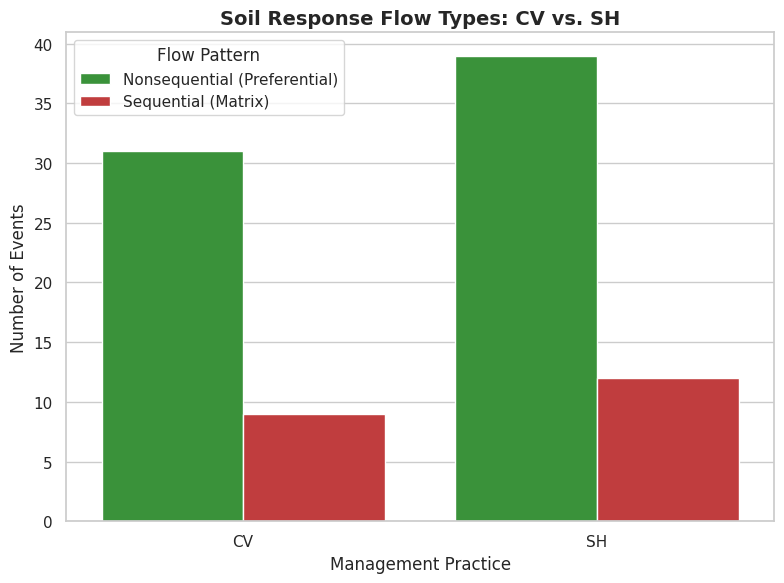

💾 Success! The flow summary has been saved to your Drive at: /content/drive/MyDrive/Preferential-Flow/Individual_Events/Nonsequential_Flow_Summary.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------------
# 1. USER PARAMETERS
# ---------------------------------------------------------
rain_threshold = 25.0
response_threshold = 0.005
pre_rain_hours = 24
post_rain_hours = 24

moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']

heavy_rain = df_p[df_p['Rainfall_mm'] >= rain_threshold].copy()
print(f"Analyzing {len(heavy_rain)} rain events for nonsequential responses...")

detected_events = []

# ---------------------------------------------------------
# 2. AUTOMATED DETECTION LOOP
# ---------------------------------------------------------
for index, event in heavy_rain.iterrows():
    f_name = event['F_name']
    anon_farm_id = event['Anon_Farm_ID']
    state = event['State']
    site_num = str(event['Site'])
    om = event['OM']
    texture = event['Texture']
    rain_date = event['Date']
    precip_amount = event['Rainfall_mm']

    window_start = rain_date - pd.Timedelta(hours=pre_rain_hours)
    window_end = rain_date + pd.Timedelta(hours=post_rain_hours)

    # FIXED: Filtering directly using existing columns instead of Base_Site_ID
    mask = (
        (df_m['F_name'] == f_name) &
        (df_m['State'] == state) &
        (df_m['Site'].astype(str) == site_num) &
        (df_m['Date'] >= window_start) &
        (df_m['Date'] <= window_end)
    )
    site_event_data = df_m[mask].copy()

    if site_event_data.empty:
        continue

    for mgmt in site_event_data['Management'].unique():
        unit_data = site_event_data[site_event_data['Management'] == mgmt].copy()

        unit_data = unit_data.set_index('Date').resample('15min').mean(numeric_only=True)
        unit_data = unit_data.interpolate(method='time')
        smoothed_data = unit_data.rolling(window=3, min_periods=1).mean()

        response_times = {}

        for col in moisture_cols:
            if col not in smoothed_data.columns or smoothed_data[col].isna().all():
                continue

            pre_rain_mask = smoothed_data.index < rain_date
            if pre_rain_mask.any():
                baseline = smoothed_data.loc[pre_rain_mask, col].mean()
            else:
                baseline = smoothed_data[col].iloc[0]

            triggered_points = smoothed_data[smoothed_data[col] >= (baseline + response_threshold)]

            if not triggered_points.empty:
                response_times[col] = triggered_points.index[0]
            else:
                response_times[col] = pd.NaT

        # --- EVALUATE SEQUENTIAL VS NONSEQUENTIAL ---
        if '10_M' in response_times and pd.notna(response_times['10_M']):
            time_10cm = response_times['10_M']
            is_nonsequential = False
            bypassed_to_depth = None

            for deep_col in ['20_M', '40_M', '60_M', '80_M', '100_M']:
                if deep_col in response_times and pd.notna(response_times[deep_col]):
                    if response_times[deep_col] <= time_10cm:
                        is_nonsequential = True
                        bypassed_to_depth = deep_col
                        break

            entry = {
                'Farm': f_name,
                'Anon_Farm_ID': anon_farm_id,
                'State': state,
                'Site': site_num,
                'Management': mgmt,
                'OM': om,
                'Texture': texture,
                'Rain_Date': rain_date,
                'Precip_mm': precip_amount,
                'Flow_Type': 'Nonsequential (Preferential)' if is_nonsequential else 'Sequential (Matrix)',
                'Deepest_Bypass_Depth': bypassed_to_depth if is_nonsequential else 'None',
                '10cm_Response_Time': time_10cm
            }

            for col in moisture_cols:
                entry[f'{col}_Response'] = response_times.get(col, pd.NaT)

            detected_events.append(entry)

df_flow_summary = pd.DataFrame(detected_events)
print(f"✅ Finished! Evaluated {len(df_flow_summary)} site-management events.\n")

# ---------------------------------------------------------
# 3. SUMMARY TABLE & VISUALIZATION
# ---------------------------------------------------------
if not df_flow_summary.empty:
    print("="*50)
    print("📊 FLOW PATTERN SUMMARY (Percentage)")
    print("="*50)

    # Calculate percentages for the table
    summary_table = pd.crosstab(df_flow_summary['Management'], df_flow_summary['Flow_Type'], normalize='index') * 100
    print(summary_table.round(1).astype(str) + '%')

    # Plot the results
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6))

    # Count the raw numbers for the plot
    plot_data = df_flow_summary.groupby(['Management', 'Flow_Type']).size().reset_index(name='Count')

    sns.barplot(data=plot_data, x='Management', y='Count', hue='Flow_Type', palette=['#2ca02c', '#d62728'])
    plt.title('Soil Response Flow Types: CV vs. SH', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Events', fontsize=12)
    plt.xlabel('Management Practice', fontsize=12)
    plt.legend(title='Flow Pattern')
    plt.tight_layout()
    plt.show()
else:
    print("No complete events were detected to plot.")

# ---------------------------------------------------------
# 4. SAVE TO GOOGLE DRIVE
# ---------------------------------------------------------
# Using 'MyDrive' (no space) to avoid the phantom folder trap!
output_dir = '/content/drive/MyDrive/Preferential-Flow/Individual_Events'
os.makedirs(output_dir, exist_ok=True)

# Create a clear file name for this specific analysis
output_file = os.path.join(output_dir, 'Nonsequential_Flow_Summary.csv')

# Save the DataFrame to CSV (index=False prevents it from saving the row numbers)
df_flow_summary.to_csv(output_file, index=False)

print(f"💾 Success! The flow summary has been saved to your Drive at: {output_file}")

###Nonsequential response - statistics

####Chi-Square

In [ ]:
import scipy.stats as stats
import pandas as pd

# 1. Read the CSV path into a DataFrame
file_path = '/content/drive/MyDrive/Preferential-Flow/Individual_Events/Nonsequential_Flow_Summary.csv'
df_flow_summary = pd.read_csv(file_path)

# 2. Create contingency table of counts
contingency_table = pd.crosstab(df_flow_summary['Management'], df_flow_summary['Flow_Type'])
print("📊 CONTINGENCY TABLE (Event Counts):")
print(contingency_table)
print("-" * 50)

# 3. Chi-Square Test of Independence
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"p-value              : {p_val:.4e}")

if p_val < 0.05:
    print("✨ RESULT: Significant difference (p < 0.05)! Flow pattern distribution depends on Management practice.")
else:
    print("RESULT: No significant difference (p >= 0.05) in flow patterns between CV and SH.")

📊 CONTINGENCY TABLE (Event Counts):
Flow_Type   Nonsequential (Preferential)  Sequential (Matrix)
Management                                                   
CV                                    31                    9
SH                                    39                   12
--------------------------------------------------
Chi-Square Statistic : 0.0000
Degrees of Freedom   : 1
p-value              : 1.0000e+00
RESULT: No significant difference (p >= 0.05) in flow patterns between CV and SH.


####PCA

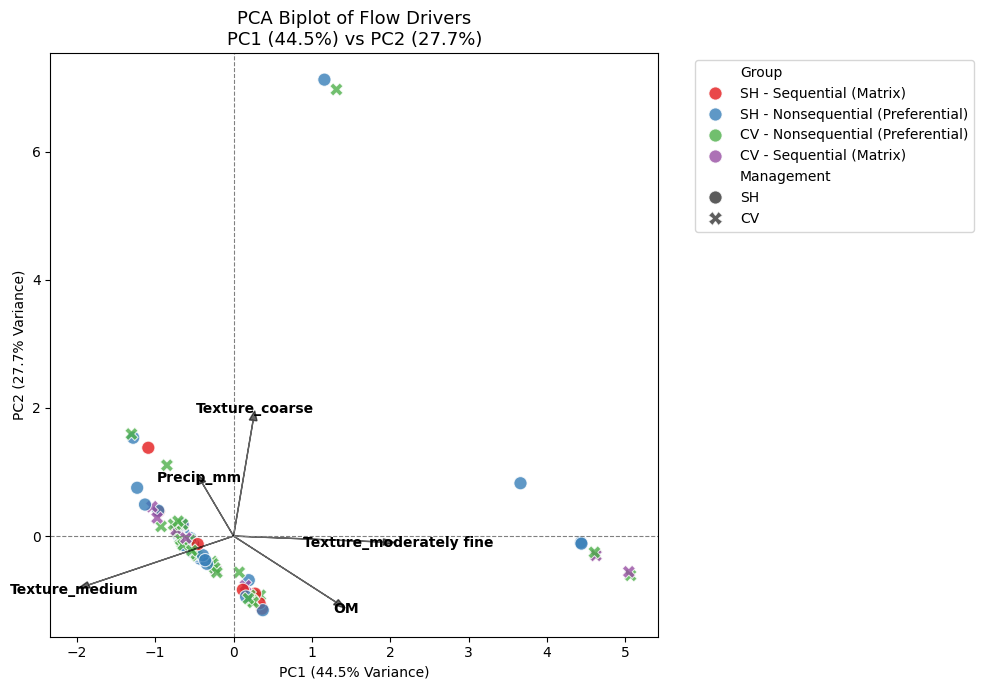


📈 FEATURE LOADINGS ON PRINCIPAL COMPONENTS:
                         PC1_Loading  PC2_Loading
Precip_mm                     -0.134        0.350
OM                             0.436       -0.436
Texture_coarse                 0.083        0.763
Texture_medium                -0.616       -0.322
Texture_moderately fine        0.637       -0.039


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Drop missing values in key predictors
pca_cols = ['Precip_mm', 'OM', 'Texture', 'Management', 'Flow_Type']
df_pca = df_flow_summary[pca_cols].dropna().copy()

# One-hot encode categorical Texture
features_raw = pd.get_dummies(df_pca[['Precip_mm', 'OM', 'Texture']], columns=['Texture'], drop_first=False)
feature_names = features_raw.columns

# Standardize features (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_raw)

# Fit PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

df_pca['PC1'] = pca_coords[:, 0]
df_pca['PC2'] = pca_coords[:, 1]
df_pca['Group'] = df_pca['Management'] + " - " + df_pca['Flow_Type']

# Plot PCA Scatter
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='Group',
    style='Management', s=90, palette='Set1', alpha=0.8
)

# Plot Feature Loadings (Vectors)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2, color='black', alpha=0.6, head_width=0.1)
    plt.text(loadings[i, 0]*2.2, loadings[i, 1]*2.2, feature, color='black', ha='center', va='center', fontweight='bold')

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.title(f'PCA Biplot of Flow Drivers\nPC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) vs PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print Feature Loadings Table
loadings_df = pd.DataFrame(pca.components_.T, index=feature_names, columns=['PC1_Loading', 'PC2_Loading'])
print("\n📈 FEATURE LOADINGS ON PRINCIPAL COMPONENTS:")
print(loadings_df.round(3))

####Random Forest
Drivers of preferential flow

/tmp/ipykernel_441/196994313.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp, x='Importance_Pct', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipykernel_441/196994313.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp, x='Importance_Pct', y='Feature', ax=axes[i], palette='viridis')


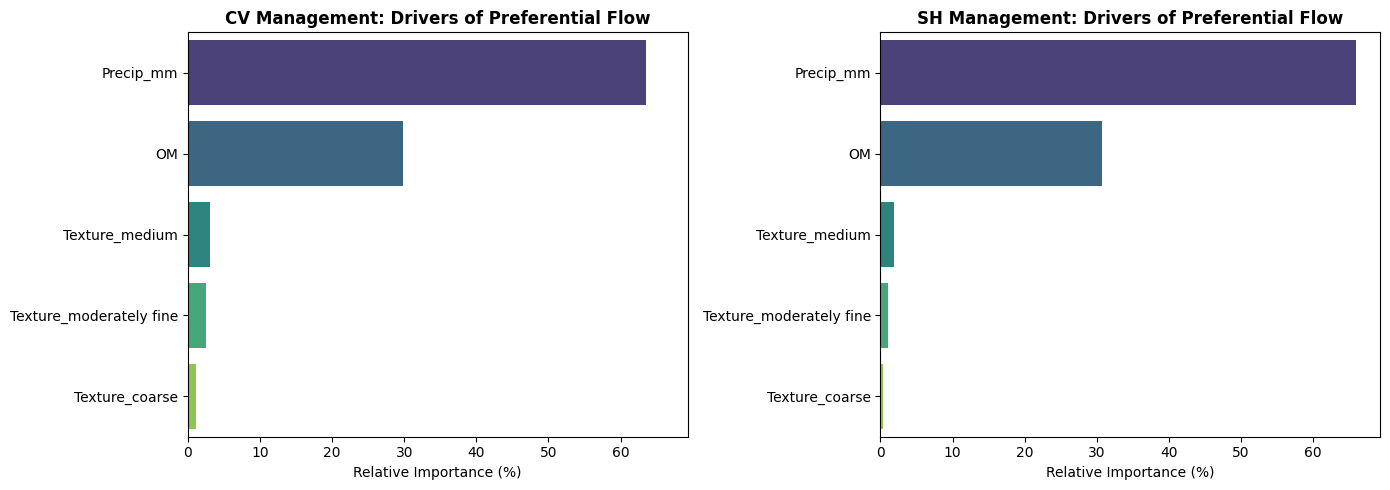


📊 FEATURE IMPORTANCE WEIGHTS (CV):
                Feature  Importance_Pct
              Precip_mm       63.556418
                     OM       29.818489
         Texture_medium        2.988948
Texture_moderately fine        2.521994
         Texture_coarse        1.114151

📊 FEATURE IMPORTANCE WEIGHTS (SH):
                Feature  Importance_Pct
              Precip_mm       65.978530
                     OM       30.775926
         Texture_medium        1.855139
Texture_moderately fine        1.083578
         Texture_coarse        0.306828


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

file_path = '/content/drive/MyDrive/Preferential-Flow/Individual_Events/Nonsequential_Flow_Summary.csv'
df_flow_summary = pd.read_csv(file_path)

# Prepare filtered dataset
rf_cols = ['Precip_mm', 'OM', 'Texture', 'Management', 'Flow_Type']
df_rf = df_flow_summary[rf_cols].dropna().copy()

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for i, mgmt in enumerate(['CV', 'SH']):
    sub_df = df_rf[df_rf['Management'] == mgmt].copy()

    # Target: 1 for Nonsequential, 0 for Sequential
    y = (sub_df['Flow_Type'].str.contains('Nonsequential')).astype(int)

    # One-hot encode predictors (Precip, OM, Texture)
    X = pd.get_dummies(sub_df[['Precip_mm', 'OM', 'Texture']], drop_first=False)

    # Fit Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)
    rf.fit(X, y)

    # Extract Feature Importances
    imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance_Pct': rf.feature_importances_ * 100
    }).sort_values(by='Importance_Pct', ascending=False)

    results[mgmt] = imp

    # Plot side-by-side
    sns.barplot(data=imp, x='Importance_Pct', y='Feature', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{mgmt} Management: Drivers of Preferential Flow', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Relative Importance (%)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# Print comparative results
for mgmt, df_imp in results.items():
    print(f"\n📊 FEATURE IMPORTANCE WEIGHTS ({mgmt}):")
    print(df_imp.to_string(index=False))

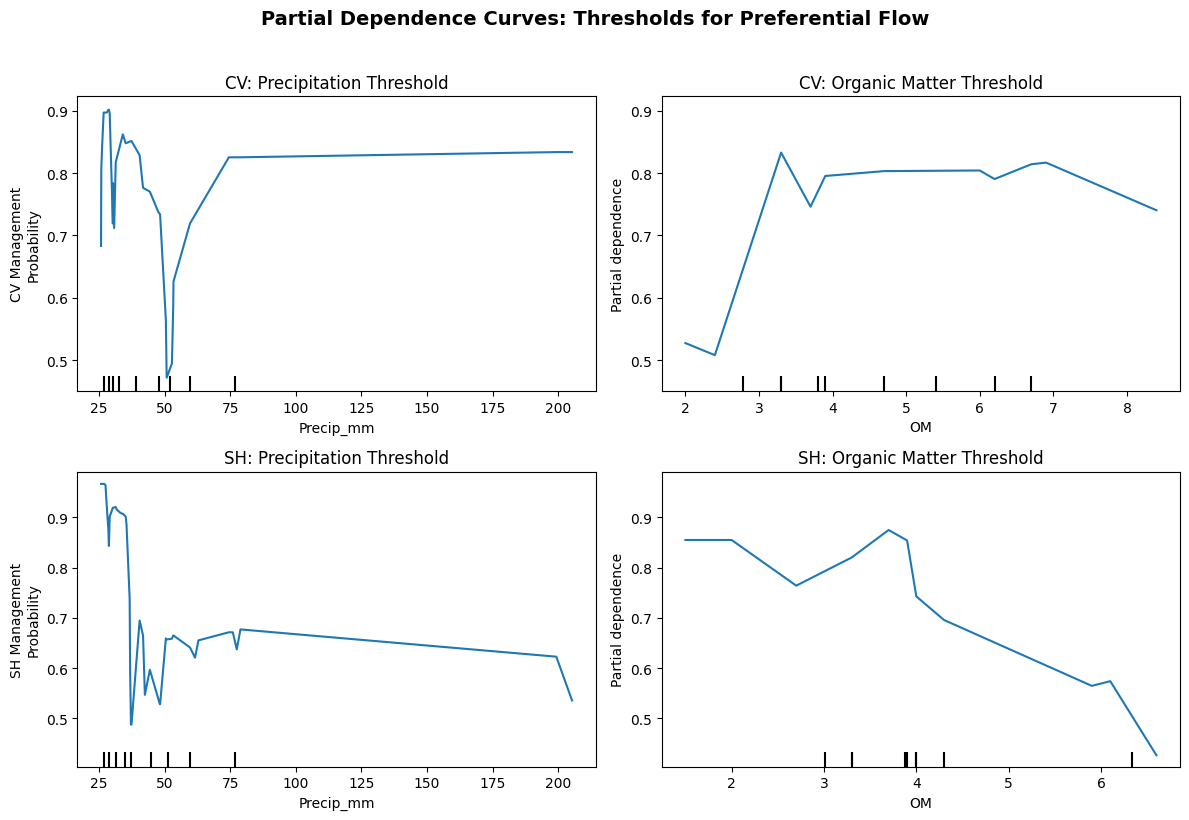

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

# ---------------------------------------------------------
# 1. PREPARE CLEAN SUBGROUP DATASETS
# ---------------------------------------------------------
rf_cols = ['Precip_mm', 'OM', 'Texture', 'Management', 'Flow_Type']
df_rf = df_flow_summary[rf_cols].dropna().copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ---------------------------------------------------------
# 2. FIT MODELS & PLOT PARTIAL DEPENDENCE FOR CV & SH
# ---------------------------------------------------------
for idx, mgmt in enumerate(['CV', 'SH']):
    sub_df = df_rf[df_rf['Management'] == mgmt].copy()

    # Target: 1 = Nonsequential, 0 = Sequential
    y_sub = (sub_df['Flow_Type'].str.contains('Nonsequential')).astype(int)
    X_sub = pd.get_dummies(sub_df[['Precip_mm', 'OM', 'Texture']], drop_first=False)

    # Fit dedicated model per management practice
    rf_sub = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)
    rf_sub.fit(X_sub, y_sub)

    # Generate PDP curves for Precip_mm and OM
    PartialDependenceDisplay.from_estimator(
        rf_sub,
        X_sub,
        features=['Precip_mm', 'OM'],
        grid_resolution=50,
        ax=axes[idx]
    )

    # Format Subplot Headers
    axes[idx, 0].set_ylabel(f'{mgmt} Management\nProbability')
    axes[idx, 0].set_title(f'{mgmt}: Precipitation Threshold')
    axes[idx, 1].set_title(f'{mgmt}: Organic Matter Threshold')

plt.suptitle('Partial Dependence Curves: Thresholds for Preferential Flow', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

####Random Forest
Drivers of sequential flow

/tmp/ipykernel_541/42636251.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp, x='Importance_Pct', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipykernel_541/42636251.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp, x='Importance_Pct', y='Feature', ax=axes[i], palette='viridis')


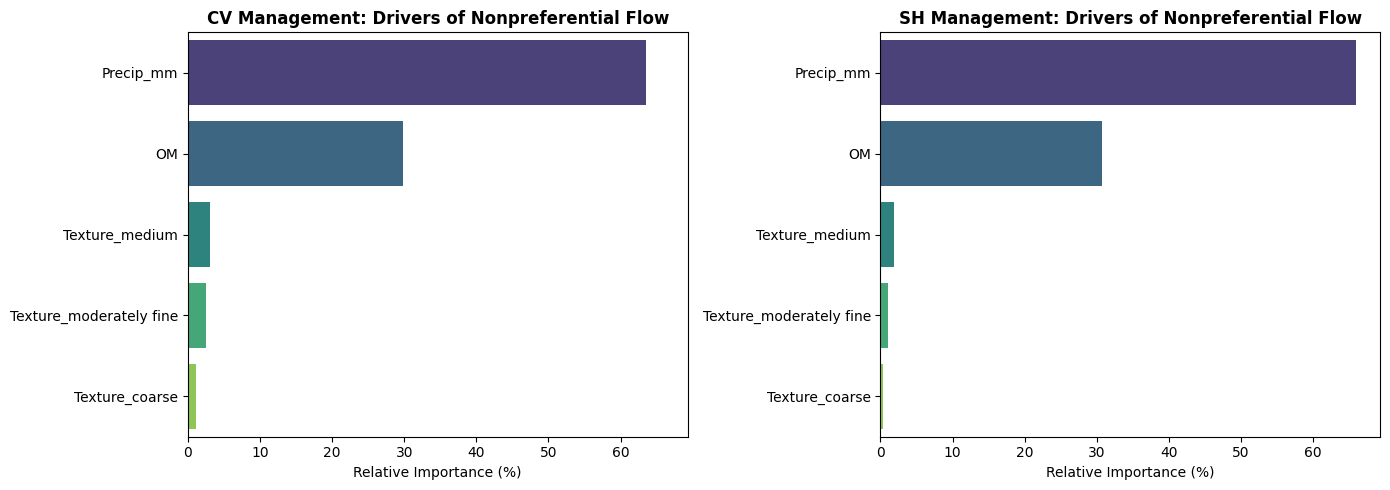


📊 FEATURE IMPORTANCE WEIGHTS (CV):
                Feature  Importance_Pct
              Precip_mm       63.556418
                     OM       29.818489
         Texture_medium        2.988948
Texture_moderately fine        2.521994
         Texture_coarse        1.114151

📊 FEATURE IMPORTANCE WEIGHTS (SH):
                Feature  Importance_Pct
              Precip_mm       65.978530
                     OM       30.775926
         Texture_medium        1.855139
Texture_moderately fine        1.083578
         Texture_coarse        0.306828


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

file_path = '/content/drive/MyDrive/Preferential-Flow/Individual_Events/Nonsequential_Flow_Summary.csv'
df_flow_summary = pd.read_csv(file_path)

# Prepare filtered dataset
rf_cols = ['Precip_mm', 'OM', 'Texture', 'Management', 'Flow_Type']
df_rf = df_flow_summary[rf_cols].dropna().copy()

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for i, mgmt in enumerate(['CV', 'SH']):
    sub_df = df_rf[df_rf['Management'] == mgmt].copy()

    # Target: 1 for Nonsequential, 0 for Sequential
    y = (sub_df['Flow_Type'].str.contains('Sequential')).astype(int)

    # One-hot encode predictors (Precip, OM, Texture)
    X = pd.get_dummies(sub_df[['Precip_mm', 'OM', 'Texture']], drop_first=False)

    # Fit Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)
    rf.fit(X, y)

    # Extract Feature Importances
    imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance_Pct': rf.feature_importances_ * 100
    }).sort_values(by='Importance_Pct', ascending=False)

    results[mgmt] = imp

    # Plot side-by-side
    sns.barplot(data=imp, x='Importance_Pct', y='Feature', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{mgmt} Management: Drivers of Nonpreferential Flow', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Relative Importance (%)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# Print comparative results
for mgmt, df_imp in results.items():
    print(f"\n📊 FEATURE IMPORTANCE WEIGHTS ({mgmt}):")
    print(df_imp.to_string(index=False))

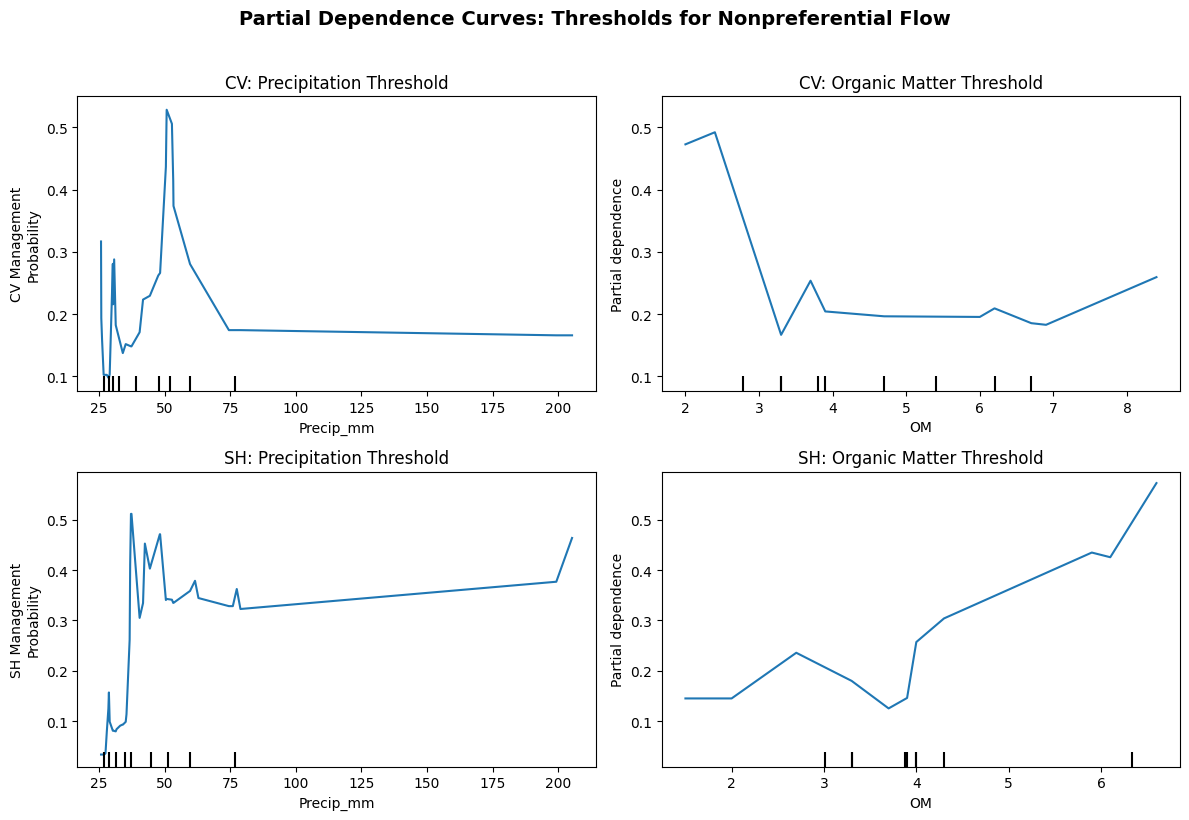

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

# ---------------------------------------------------------
# 1. PREPARE CLEAN SUBGROUP DATASETS
# ---------------------------------------------------------
rf_cols = ['Precip_mm', 'OM', 'Texture', 'Management', 'Flow_Type']
df_rf = df_flow_summary[rf_cols].dropna().copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ---------------------------------------------------------
# 2. FIT MODELS & PLOT PARTIAL DEPENDENCE FOR CV & SH
# ---------------------------------------------------------
for idx, mgmt in enumerate(['CV', 'SH']):
    sub_df = df_rf[df_rf['Management'] == mgmt].copy()

    # Target: 1 = Nonsequential, 0 = Sequential
    y_sub = (sub_df['Flow_Type'].str.contains('Sequential')).astype(int)
    X_sub = pd.get_dummies(sub_df[['Precip_mm', 'OM', 'Texture']], drop_first=False)

    # Fit dedicated model per management practice
    rf_sub = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)
    rf_sub.fit(X_sub, y_sub)

    # Generate PDP curves for Precip_mm and OM
    PartialDependenceDisplay.from_estimator(
        rf_sub,
        X_sub,
        features=['Precip_mm', 'OM'],
        grid_resolution=50,
        ax=axes[idx]
    )

    # Format Subplot Headers
    axes[idx, 0].set_ylabel(f'{mgmt} Management\nProbability')
    axes[idx, 0].set_title(f'{mgmt}: Precipitation Threshold')
    axes[idx, 1].set_title(f'{mgmt}: Organic Matter Threshold')

plt.suptitle('Partial Dependence Curves: Thresholds for Nonpreferential Flow', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#Frequency-domain analysis for events of >25 mm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pywt
import os

# ---------------------------------------------------------
# 1. SETUP & FILTERING
# ---------------------------------------------------------
output_dir = '/content/drive/My Drive/Preferential-Flow/Wavelet_Events_25mm'
os.makedirs(output_dir, exist_ok=True)

rain_threshold = 25.0

# THE FIX: Create the 'Base_Site_ID' column in df_m so we can search by it!
df_m['Base_Site_ID'] = df_m['Anon_Farm_ID'].astype(str) + "_" + df_m['State'].astype(str) + "_Site-" + df_m['Site'].astype(str)

# Filter for events with 25mm or more of rain
heavy_rain = df_p[df_p['Rainfall_mm'] >= rain_threshold].copy()
print(f"Found {len(heavy_rain)} qualifying rain events (>= 25mm). Generating Wavelet plots...")

plots_generated = 0
moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']
wavelet = 'morl'
scales = np.arange(1, 128)

# ---------------------------------------------------------
# 2. AUTOMATED EVENT LOOP
# ---------------------------------------------------------
for index, event in heavy_rain.iterrows():
    farm = event['Anon_Farm_ID']
    state = event['State']
    site_num = str(event['Site'])
    rain_date = event['Date']
    precip_amount = event['Rainfall_mm']

    # Base site to match moisture data
    base_site = f"{farm}_{state}_Site-{site_num}"

    # 48 hours before, 72 hours after (adjust if you prefer a different window)
    window_start = rain_date - pd.Timedelta(days=2)
    window_end = rain_date + pd.Timedelta(days=3)

    # Isolate ALL moisture data for this physical location and time window
    mask = (df_m['Base_Site_ID'] == base_site) & (df_m['Date'] >= window_start) & (df_m['Date'] <= window_end)
    site_event_data = df_m[mask].copy()

    if site_event_data.empty:
        continue

    # Loop through each management type found at this site
    available_managements = site_event_data['Management'].unique()

    for mgmt in available_managements:
        unit_data = site_event_data[site_event_data['Management'] == mgmt].copy()

        # Resample to 30min and interpolate gaps for the wavelet math
        unit_data = unit_data.set_index('Date').resample('15min').mean(numeric_only=True)
        unit_data = unit_data.interpolate(method='time')

        # Skip if the whole interpolated block is just NaNs
        if unit_data[moisture_cols].isna().all().all():
            continue

        x_times = mdates.date2num(unit_data.index)

        # ---------------------------------------------------------
        # 3. PLOTTING THE 6-STACK SCALOGRAMS
        # ---------------------------------------------------------
        fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

        date_str = rain_date.strftime('%Y-%m-%d')
        clean_site = site_num if "Site" in site_num else f"Site {site_num}"
        fig.suptitle(f'Wavelet Analysis: {farm}, {state} | {clean_site} | Mgmt: {mgmt}\nRainfall: {precip_amount}mm on {date_str}', fontsize=16, fontweight='bold', y=0.92)

        for i, col in enumerate(moisture_cols):
            ax = axes[i]
            signal = unit_data[col].values

            # Safety Check: If a sensor is broken, leave the plot blank and add text
            if np.isnan(signal).all():
                ax.text(0.5, 0.5, f"No Data for {col}", transform=ax.transAxes, ha='center', va='center', fontsize=12)
                ax.set_ylabel(f'{col.replace("_M", "m")}\nScale', fontsize=10, fontweight='bold')
                ax.invert_yaxis()
                continue

            # Compute Wavelet
            coefficients, frequencies = pywt.cwt(signal, scales, wavelet)
            power = (abs(coefficients)) ** 2

            # Plot Scalogram
            im = ax.contourf(x_times, scales, power, extend='both', cmap='jet', levels=100)

            ax.set_ylabel(f'{col.replace("_M", "m")}\nScale', fontsize=12, fontweight='bold')
            ax.axvline(rain_date, color='white', linestyle='--', alpha=0.8, linewidth=2) # Mark rain start
            ax.invert_yaxis()
            ax.set_yscale('log', base=2)

            cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.01, aspect=15)
            cbar.ax.tick_params(labelsize=8)

        # Bottom X-axis formatting
        axes[-1].set_xlabel('Date', fontsize=14, fontweight='bold')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))

        plt.tight_layout()
        plt.subplots_adjust(hspace=0.15, top=0.88)

        # Save and close
        unit_id_str = f"{base_site}_{mgmt}"
        output_path = os.path.join(output_dir, f'Wavelet_{unit_id_str}_{date_str}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()

        plots_generated += 1

print(f"Analysis complete! Saved {plots_generated} wavelet plots to your Google Drive folder: 'Wavelet_Events_25mm'")

Found 120 qualifying rain events (>= 25mm). Generating Wavelet plots...
Analysis complete! Saved 111 wavelet plots to your Google Drive folder: 'Wavelet_Events_25mm'


#Identifying events with possible PF based on "score"

In [ ]:
import pandas as pd
import numpy as np
import pywt

# 1. SETUP & FILTERING
rain_threshold = 25.0
heavy_rain = df_p[df_p['Rainfall_mm'] >= rain_threshold].copy()
print(f"Scanning {len(heavy_rain)} rain events for Preferential Flow signatures...")

moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']
wavelet = 'morl'
scales = np.arange(1, 128)

ranking_results = []

# 2. THE MATHEMATICAL SCANNER
for index, event in heavy_rain.iterrows():
    farm = event['Anon_Farm_ID']
    state = event['State']
    site_num = str(event['Site'])
    rain_date = event['Date']
    precip = event['Rainfall_mm']

    base_site = f"{farm}_{state}_Site-{site_num}"

    # New Window: 24 hours before the timestamp to 12 hours after
    window_start = rain_date - pd.Timedelta(hours=24)
    window_end = rain_date + pd.Timedelta(hours=12)

    mask = (df_m['Base_Site_ID'] == base_site) & (df_m['Date'] >= window_start) & (df_m['Date'] <= window_end)
    site_event_data = df_m[mask].copy()

    if site_event_data.empty:
        continue

    for mgmt in site_event_data['Management'].unique():
        unit_data = site_event_data[site_event_data['Management'] == mgmt].copy()

        # YOUR FIXES: 15-minute intervals and 'time' interpolation
        unit_data = unit_data.set_index('Date').resample('15min').mean(numeric_only=True)
        unit_data = unit_data.interpolate(method='time')

        if unit_data[moisture_cols].isna().all().all():
            continue

        total_pf_power = 0
        valid_sensors = 0

        # Calculate high-frequency power for ALL sensors
        for col in moisture_cols:
            signal = unit_data[col].values
            if not np.isnan(signal).all():
                coefficients, _ = pywt.cwt(signal, scales, wavelet)
                power = (abs(coefficients)) ** 2

                # ISOLATE HIGH FREQUENCY: We only look at scales 1 through 16
                # (Representing rapid changes occurring within 15 mins to 4 hours)
                high_freq_power = power[0:16, :].mean()
                total_pf_power += high_freq_power
                valid_sensors += 1

        # Average the score across however many sensors were working
        if valid_sensors > 0:
            event_score = total_pf_power / valid_sensors

            ranking_results.append({
                'Farm': farm,
                'State': state,
                'Site': site_num,
                'Management': mgmt,
                'Rain_Date': rain_date,
                'Precip_mm': precip,
                'PF_Score': event_score
            })

# 3. SHOW THE TOP 10 EVENTS
df_ranking = pd.DataFrame(ranking_results)
df_ranking = df_ranking.sort_values(by='PF_Score', ascending=False).reset_index(drop=True)

print("\n🏆 Top 10 Events Most Likely to Show Preferential Flow:")
print(df_ranking.head(10).to_string())

Scanning 120 rain events for Preferential Flow signatures...

🏆 Top 10 Events Most Likely to Show Preferential Flow:
      Farm State      Site Management  Rain_Date  Precip_mm  PF_Score
0  Farm_28    MN  Freeborn         CV 2022-07-23       44.4  0.010071
1  Farm_10    WI     Dodge         SH 2022-07-15       50.5  0.005670
2  Farm_12    MN  Freeborn         SH 2022-08-28       34.1  0.003890
3  Farm_12    MN  Freeborn         SH 2022-07-05       48.2  0.003861
4  Farm_12    MN  Freeborn         SH 2022-06-25       31.7  0.003834
5  Farm_12    MN  Freeborn         SH 2022-06-15       35.5  0.003806
6  Farm_12    MN  Freeborn         SH 2022-07-04       42.5  0.003795
7  Farm_12    MN  Freeborn         SH 2023-09-23       26.8  0.003790
8  Farm_12    MN  Freeborn         SH 2021-08-27      199.2  0.003646
9  Farm_12    MN  Freeborn         SH 2022-07-23       44.4  0.003641


#Plot example based on score list

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pywt

# --- PLUG IN YOUR #1 RANKED EVENT HERE ---
target_farm = 'Farm_33'
target_state = 'WI'
target_site = 'Dodge'
target_mgmt = 'CV'
target_date_str = '2022-07-23'
target_date = pd.to_datetime(target_date_str)
# ----------------------------------------

unit_id = f"{target_farm}_{target_state}_Site-{target_site}_{target_mgmt}"
base_site = f"{target_farm}_{target_state}_Site-{target_site}"

# New 36-Hour Window
window_start = target_date - pd.Timedelta(hours=24)
window_end = target_date + pd.Timedelta(hours=12)

mask = (df_m['Base_Site_ID'] == base_site) & (df_m['Management'] == target_mgmt) & (df_m['Date'] >= window_start) & (df_m['Date'] <= window_end)
event_data = df_m[mask].copy()

if event_data.empty:
    print(f"❌ ERROR: No data found for {unit_id}.")
else:
    print(f"✅ Data found! Generating High-Res Wavelet...")

    # 15min Resampling & Time Interpolation
    event_data = event_data.set_index('Date').resample('15min').mean(numeric_only=True)
    event_data = event_data.interpolate(method='time')

    moisture_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']
    wavelet = 'morl'
    scales = np.arange(1, 128)
    x_times = mdates.date2num(event_data.index)

    fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
    fig.suptitle(f'High-Res Wavelet: {unit_id}\nRain Recorded on: {target_date_str}', fontsize=16, fontweight='bold', y=0.92)

    for i, col in enumerate(moisture_cols):
        ax = axes[i]
        signal = event_data[col].values

        if np.isnan(signal).all():
            ax.text(0.5, 0.5, f"No Data for {col}", transform=ax.transAxes, ha='center', va='center', fontsize=12)
            ax.set_ylabel(f'{col.replace("_M", "m")}\nScale', fontsize=10, fontweight='bold')
            ax.invert_yaxis()
            continue

        coefficients, frequencies = pywt.cwt(signal, scales, wavelet)
        power = (abs(coefficients)) ** 2

        im = ax.contourf(x_times, scales, power, extend='both', cmap='jet', levels=100)

        ax.set_ylabel(f'{col.replace("_M", "m")}\nScale', fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.set_yscale('log', base=2)

        # Shade the 24 hours prior to the timestamp to show when rain occurred
        ax.axvspan(window_start, target_date, color='blue', alpha=0.1, label='Rain Accumulation Window' if i==0 else "")
        ax.axvline(target_date, color='blue', linestyle='--', alpha=0.8, linewidth=2)

        if i == 0:
            ax.legend(loc='upper right')

        cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.01, aspect=15)
        cbar.ax.tick_params(labelsize=8)

    axes[-1].set_xlabel('Date & Time', fontsize=14, fontweight='bold')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.15, top=0.88)
    plt.show()

#Calculating wavelet metrics

Coherence and phase-shift


In [ ]:
import pandas as pd
import numpy as np
import pywt
import os

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
output_dir = '/content/drive/MyDrive/Preferential-Flow/Wavelet_Metrics'
os.makedirs(output_dir, exist_ok=True)

rain_threshold = 25.0
heavy_rain = df_p[df_p['Rainfall_mm'] >= rain_threshold].copy()
print(f"Calculating Wavelet Coherence for {len(heavy_rain)} events...")

wavelet = 'morl'
scales = np.arange(1, 128)
pad_hours = 12 # We will pad 12 hours of data on each side to fix edge effects
pad_steps = pad_hours * 4 # 4 steps per hour (15-minute intervals)

results_list = []

# Safely create the matching ID column if it doesn't exist yet
if 'Base_Site_ID' not in df_m.columns:
    df_m['Base_Site_ID'] = df_m['Anon_Farm_ID'].astype(str) + "_" + df_m['State'].astype(str) + "_Site-" + df_m['Site'].astype(str)

# ---------------------------------------------------------
# 2. AUTOMATED METRICS LOOP
# ---------------------------------------------------------
for index, event in heavy_rain.iterrows():
    farm = event['Anon_Farm_ID']
    state = event['State']
    site_num = str(event['Site'])
    rain_date = event['Date']
    precip = event['Rainfall_mm']

    base_site = f"{farm}_{state}_Site-{site_num}"

    window_start = rain_date - pd.Timedelta(hours=24 + pad_hours)
    window_end = rain_date + pd.Timedelta(hours=12 + pad_hours)

    mask = (df_m['Base_Site_ID'] == base_site) & (df_m['Date'] >= window_start) & (df_m['Date'] <= window_end)
    site_event_data = df_m[mask].copy()

    if site_event_data.empty:
        continue

    for mgmt in site_event_data['Management'].unique():
        unit_data = site_event_data[site_event_data['Management'] == mgmt].copy()

        # Resample and Interpolate
        unit_data = unit_data.set_index('Date').resample('15min').mean(numeric_only=True)
        unit_data = unit_data.interpolate(method='time')

        # We MUST have the 10cm sensor working to act as our baseline
        if '10_M' not in unit_data.columns or unit_data['10_M'].isna().all():
            continue

        # Apply Symmetric Padding to the 10cm reference signal
        signal_10 = unit_data['10_M'].values
        sig_10_pad = np.pad(signal_10, pad_width=pad_steps, mode='symmetric')

        # Calculate 10cm Wavelet and Individual Power
        W_10, _ = pywt.cwt(sig_10_pad, scales, wavelet)
        W_10 = W_10[:, pad_steps:-pad_steps]
        Power_10 = np.abs(W_10)**2

        for deep_col in ['20_M', '40_M', '60_M', '80_M', '100_M']:
            if deep_col not in unit_data.columns:
                continue

            signal_deep = unit_data[deep_col].values
            if np.isnan(signal_deep).all():
                continue

            sig_deep_pad = np.pad(signal_deep, pad_width=pad_steps, mode='symmetric')

            # Calculate Deep Wavelet and Individual Power
            W_deep, _ = pywt.cwt(sig_deep_pad, scales, wavelet)
            W_deep = W_deep[:, pad_steps:-pad_steps]
            Power_deep = np.abs(W_deep)**2

            # --- CALCULATE CROSS-WAVELET & COHERENCE ---
            W_cross = W_10 * np.conj(W_deep)
            phase_angle = np.angle(W_cross) # Calculated in radians

            # Average the high-frequency spectra (fast changes, scales 1 to 16) over the 36-hour time window
            # during the 36-hour window
            mean_cross_mag = np.abs(np.mean(W_cross[0:16, :]))
            mean_p10 = np.mean(Power_10[0:16, :])
            mean_pdeep = np.mean(Power_deep[0:16, :])

            # Calculate True Coherence (0.0 to 1.0)
            if mean_p10 > 0 and mean_pdeep > 0:
                coherence = (mean_cross_mag**2) / (mean_p10 * mean_pdeep)
            else:
                coherence = 0.0

            high_freq_phase = np.mean(phase_angle[0:16, :])

            results_list.append({
                'Farm': farm,
                'State': state,
                'Site': site_num,
                'Management': mgmt,
                'Rain_Date': rain_date,
                'Precip_mm': precip,
                'Comparison': f'10cm_vs_{deep_col[:2]}cm',
                'Coherence_Score': round(coherence, 4), # Cleaned up to 4 decimal places!
                'Phase_Shift_Rad': round(high_freq_phase, 4) # Closer to 0 = Less delay (Preferential Flow)
            })

# ---------------------------------------------------------
# 3. EXPORT TO EXCEL/CSV
# ---------------------------------------------------------
df_metrics = pd.DataFrame(results_list)

output_file = os.path.join(output_dir, 'Wavelet_True_Coherence_Metrics.csv')
df_metrics.to_csv(output_file, index=False)

print(f"✅ Success! Calculated True Coherence for {len(df_metrics)} sensor pairs.")
print(f"Data saved to Google Drive: {output_file}")

Calculating Wavelet Coherence for 120 events...
✅ Success! Calculated True Coherence for 555 sensor pairs.
Data saved to Google Drive: /content/drive/MyDrive/Preferential-Flow/Wavelet_Metrics/Wavelet_True_Coherence_Metrics.csv


#Analyzing Coherence from wavelet metrics

✅ Loaded 555 rows of metric data.


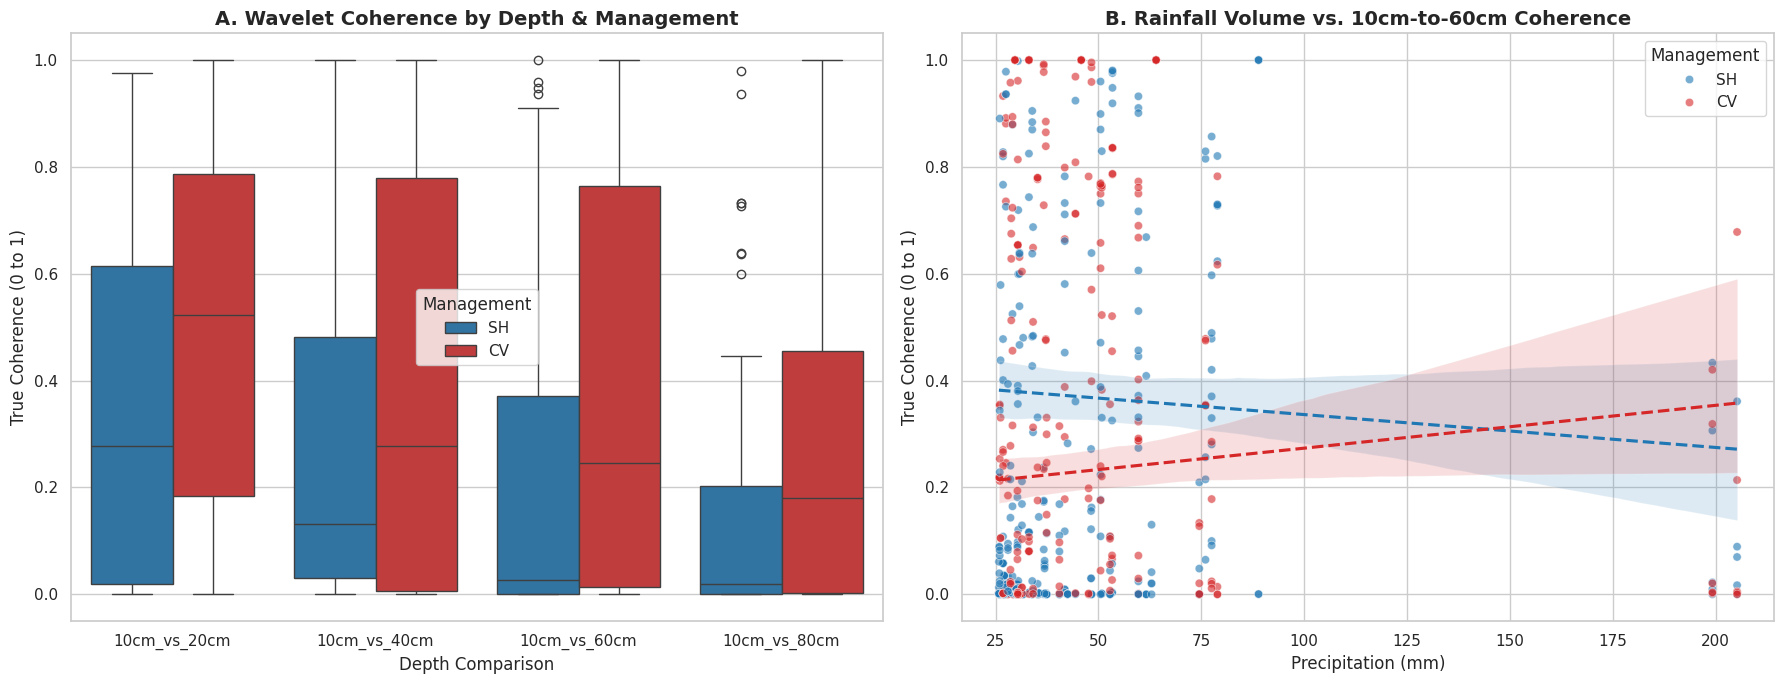


📊 STATISTICAL SUMMARY: CV vs. SH

Depth: 10cm_vs_20cm
  CV Mean Coherence: 0.511 (n=49)
  SH Mean Coherence: 0.337 (n=62)
  P-value: 0.0162 -> ⭐ SIGNIFICANT

Depth: 10cm_vs_40cm
  CV Mean Coherence: 0.409 (n=49)
  SH Mean Coherence: 0.298 (n=62)
  P-value: 0.3241 -> Not Significant

Depth: 10cm_vs_60cm
  CV Mean Coherence: 0.378 (n=49)
  SH Mean Coherence: 0.222 (n=62)
  P-value: 0.0098 -> ⭐ SIGNIFICANT

Depth: 10cm_vs_80cm
  CV Mean Coherence: 0.275 (n=49)
  SH Mean Coherence: 0.155 (n=62)
  P-value: 0.0192 -> ⭐ SIGNIFICANT

🌧️ RAINFALL CORRELATION
Spearman Correlation (Precip vs Coherence): 0.170
P-value: 0.0001 -> ⭐ SIGNIFICANT
Interpretation: Heavier rainfall significantly increases deep soil connection.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr
import os

# 1. LOAD THE DATA
file_path = '/content/drive/MyDrive/Preferential-Flow/Wavelet_Metrics/Wavelet_True_Coherence_Metrics.csv'

if not os.path.exists(file_path):
    print(f"❌ Could not find the file at {file_path}. Please check the path!")
else:
    df_metrics = pd.read_csv(file_path)
    print(f"✅ Loaded {len(df_metrics)} rows of metric data.")

    # Sort the depths so they appear in order on the graphs
    depth_order = ['10cm_vs_20cm', '10cm_vs_40cm', '10cm_vs_60cm', '10cm_vs_80cm']

    # ---------------------------------------------------------
    # 2. VISUALIZATION
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot A: Coherence by Depth and Management (Boxplot)
    sns.boxplot(data=df_metrics, x='Comparison', y='Coherence_Score', hue='Management',
                order=depth_order, palette=['#1f77b4', '#d62728'], ax=axes[0])
    axes[0].set_title('A. Wavelet Coherence by Depth & Management', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Coherence (0 to 1)', fontsize=12)
    axes[0].set_xlabel('Depth Comparison', fontsize=12)
    axes[0].set_ylim(-0.05, 1.05)

    # Plot B: Coherence vs. Precipitation Volume (Scatterplot)
    sns.scatterplot(data=df_metrics, x='Precip_mm', y='Coherence_Score', hue='Management',
                    palette=['#1f77b4', '#d62728'], alpha=0.6, ax=axes[1])
    # Add a gentle trendline for both managements
    sns.regplot(data=df_metrics[df_metrics['Management']=='CV'], x='Precip_mm', y='Coherence_Score',
                scatter=False, color='#1f77b4', ax=axes[1], line_kws={'linestyle':'--'})
    sns.regplot(data=df_metrics[df_metrics['Management']=='SH'], x='Precip_mm', y='Coherence_Score',
                scatter=False, color='#d62728', ax=axes[1], line_kws={'linestyle':'--'})

    axes[1].set_title('B. Rainfall Volume vs. 10cm-to-60cm Coherence', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Coherence (0 to 1)', fontsize=12)
    axes[1].set_xlabel('Precipitation (mm)', fontsize=12)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. STATISTICAL ANALYSIS
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("📊 STATISTICAL SUMMARY: CV vs. SH")
    print("="*50)

    for depth in depth_order:
        data_depth = df_metrics[df_metrics['Comparison'] == depth]

        cv_data = data_depth[data_depth['Management'] == 'CV']['Coherence_Score'].dropna()
        sh_data = data_depth[data_depth['Management'] == 'SH']['Coherence_Score'].dropna()

        if len(cv_data) > 0 and len(sh_data) > 0:
            # Mann-Whitney U test (Non-parametric difference of medians/distributions)
            stat, p_val = mannwhitneyu(cv_data, sh_data, alternative='two-sided')

            # Calculate means for context
            cv_mean = cv_data.mean()
            sh_mean = sh_data.mean()

            # Determine significance (p < 0.05)
            sig = "⭐ SIGNIFICANT" if p_val < 0.05 else "Not Significant"

            print(f"\nDepth: {depth}")
            print(f"  CV Mean Coherence: {cv_mean:.3f} (n={len(cv_data)})")
            print(f"  SH Mean Coherence: {sh_mean:.3f} (n={len(sh_data)})")
            print(f"  P-value: {p_val:.4f} -> {sig}")
        else:
            print(f"\nDepth: {depth} - Not enough data for comparison.")

    # Quick Correlation Check: Does more rain = more coherence?
    print("\n" + "="*50)
    print("🌧️ RAINFALL CORRELATION")
    print("="*50)
    corr, p_corr = spearmanr(df_metrics['Precip_mm'], df_metrics['Coherence_Score'], nan_policy='omit')
    sig_corr = "⭐ SIGNIFICANT" if p_corr < 0.05 else "Not Significant"
    print(f"Spearman Correlation (Precip vs Coherence): {corr:.3f}")
    print(f"P-value: {p_corr:.4f} -> {sig_corr}")
    if corr > 0 and p_corr < 0.05:
         print("Interpretation: Heavier rainfall significantly increases deep soil connection.")

#Analyzing Phase Shift from wavelet metrics

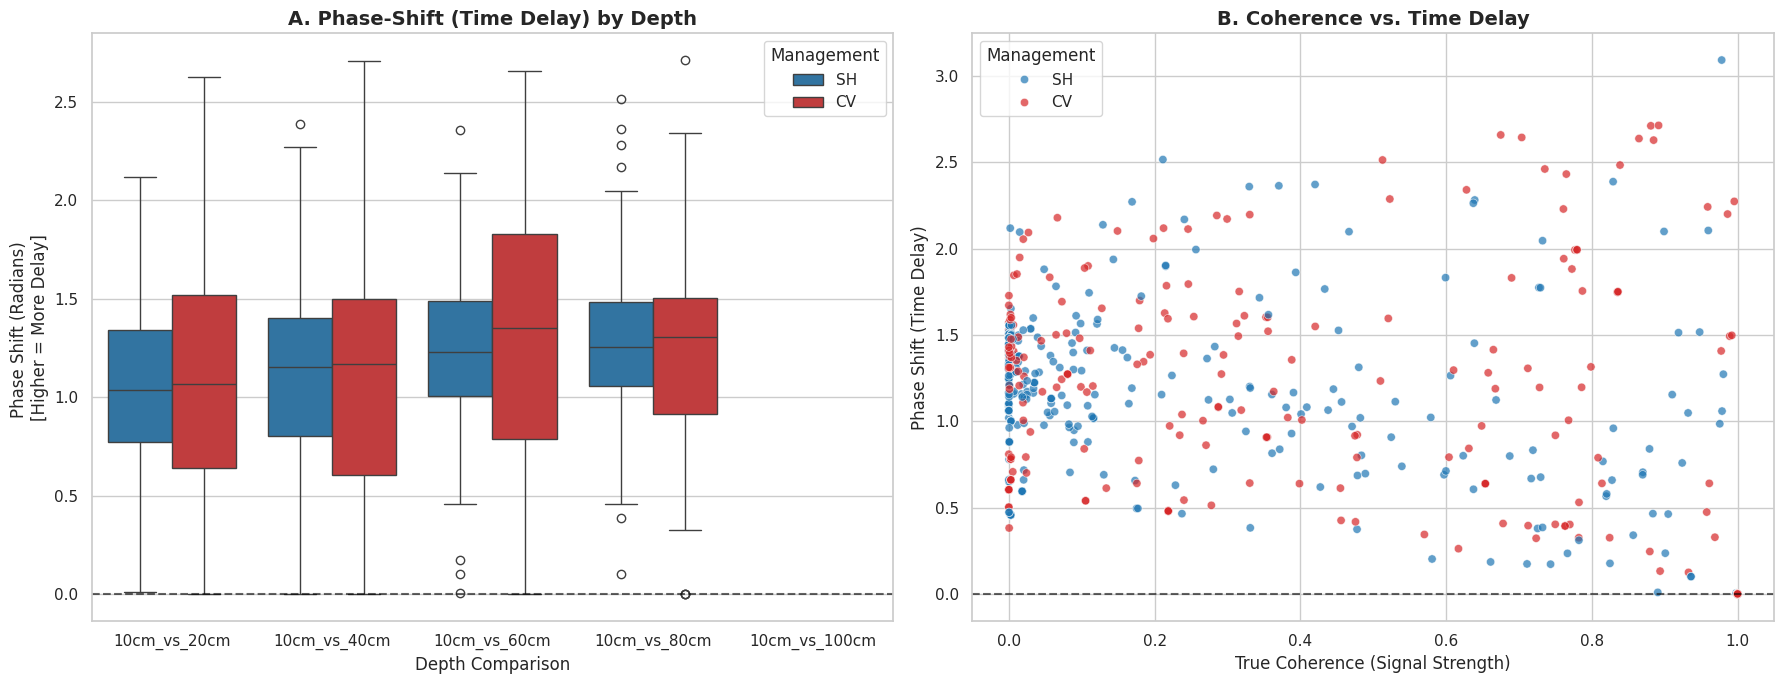


📊 PHASE-SHIFT (DELAY) STATISTICAL SUMMARY

Depth: 10cm_vs_20cm
  CV Mean Phase Shift: 1.129 rad (n=49)
  SH Mean Phase Shift: 1.031 rad (n=62)
  P-value: 0.5747 -> Not Significant

Depth: 10cm_vs_40cm
  CV Mean Phase Shift: 1.102 rad (n=49)
  SH Mean Phase Shift: 1.099 rad (n=62)
  P-value: 0.9078 -> Not Significant

Depth: 10cm_vs_60cm
  CV Mean Phase Shift: 1.307 rad (n=49)
  SH Mean Phase Shift: 1.198 rad (n=62)
  P-value: 0.2946 -> Not Significant

Depth: 10cm_vs_80cm
  CV Mean Phase Shift: 1.209 rad (n=49)
  SH Mean Phase Shift: 1.266 rad (n=62)
  P-value: 0.9337 -> Not Significant


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import os

# 1. LOAD THE DATA
file_path = '/content/drive/MyDrive/Preferential-Flow/Wavelet_Metrics/Wavelet_True_Coherence_Metrics.csv'

if not os.path.exists(file_path):
    print(f"❌ Could not find the file at {file_path}")
else:
    df_metrics = pd.read_csv(file_path)
    depth_order = ['10cm_vs_20cm', '10cm_vs_40cm', '10cm_vs_60cm', '10cm_vs_80cm', '10cm_vs_100cm']

    # ---------------------------------------------------------
    # 2. VISUALIZATION OF PHASE-SHIFT (DELAY)
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot A: Phase Shift by Depth
    sns.boxplot(data=df_metrics, x='Comparison', y='Phase_Shift_Rad', hue='Management',
                order=depth_order, palette=['#1f77b4', '#d62728'], ax=axes[0])
    axes[0].set_title('A. Phase-Shift (Time Delay) by Depth', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Phase Shift (Radians) \n[Higher = More Delay]', fontsize=12)
    axes[0].set_xlabel('Depth Comparison', fontsize=12)

    # Draw a line at 0 (Simultaneous / Preferential Flow)
    axes[0].axhline(0, color='black', linestyle='--', alpha=0.6)

    # Plot B: Phase Shift vs Coherence
    sns.scatterplot(data=df_metrics, x='Coherence_Score', y='Phase_Shift_Rad', hue='Management',
                    palette=['#1f77b4', '#d62728'], alpha=0.7, ax=axes[1])
    axes[1].set_title('B. Coherence vs. Time Delay', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('True Coherence (Signal Strength)', fontsize=12)
    axes[1].set_ylabel('Phase Shift (Time Delay)', fontsize=12)
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. STATISTICAL SUMMARY FOR PHASE-SHIFT
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("📊 PHASE-SHIFT (DELAY) STATISTICAL SUMMARY")
    print("="*50)

    for depth in depth_order:
        data_depth = df_metrics[df_metrics['Comparison'] == depth]

        cv_data = data_depth[data_depth['Management'] == 'CV']['Phase_Shift_Rad'].dropna()
        sh_data = data_depth[data_depth['Management'] == 'SH']['Phase_Shift_Rad'].dropna()

        if len(cv_data) > 0 and len(sh_data) > 0:
            stat, p_val = mannwhitneyu(cv_data, sh_data, alternative='two-sided')

            cv_mean = cv_data.mean()
            sh_mean = sh_data.mean()
            sig = "⭐ SIGNIFICANT" if p_val < 0.05 else "Not Significant"

            print(f"\nDepth: {depth}")
            print(f"  CV Mean Phase Shift: {cv_mean:.3f} rad (n={len(cv_data)})")
            print(f"  SH Mean Phase Shift: {sh_mean:.3f} rad (n={len(sh_data)})")
            print(f"  P-value: {p_val:.4f} -> {sig}")

#PCA of all wavelet metrics

✅ Data prepped for PCA. 111 complete events found.


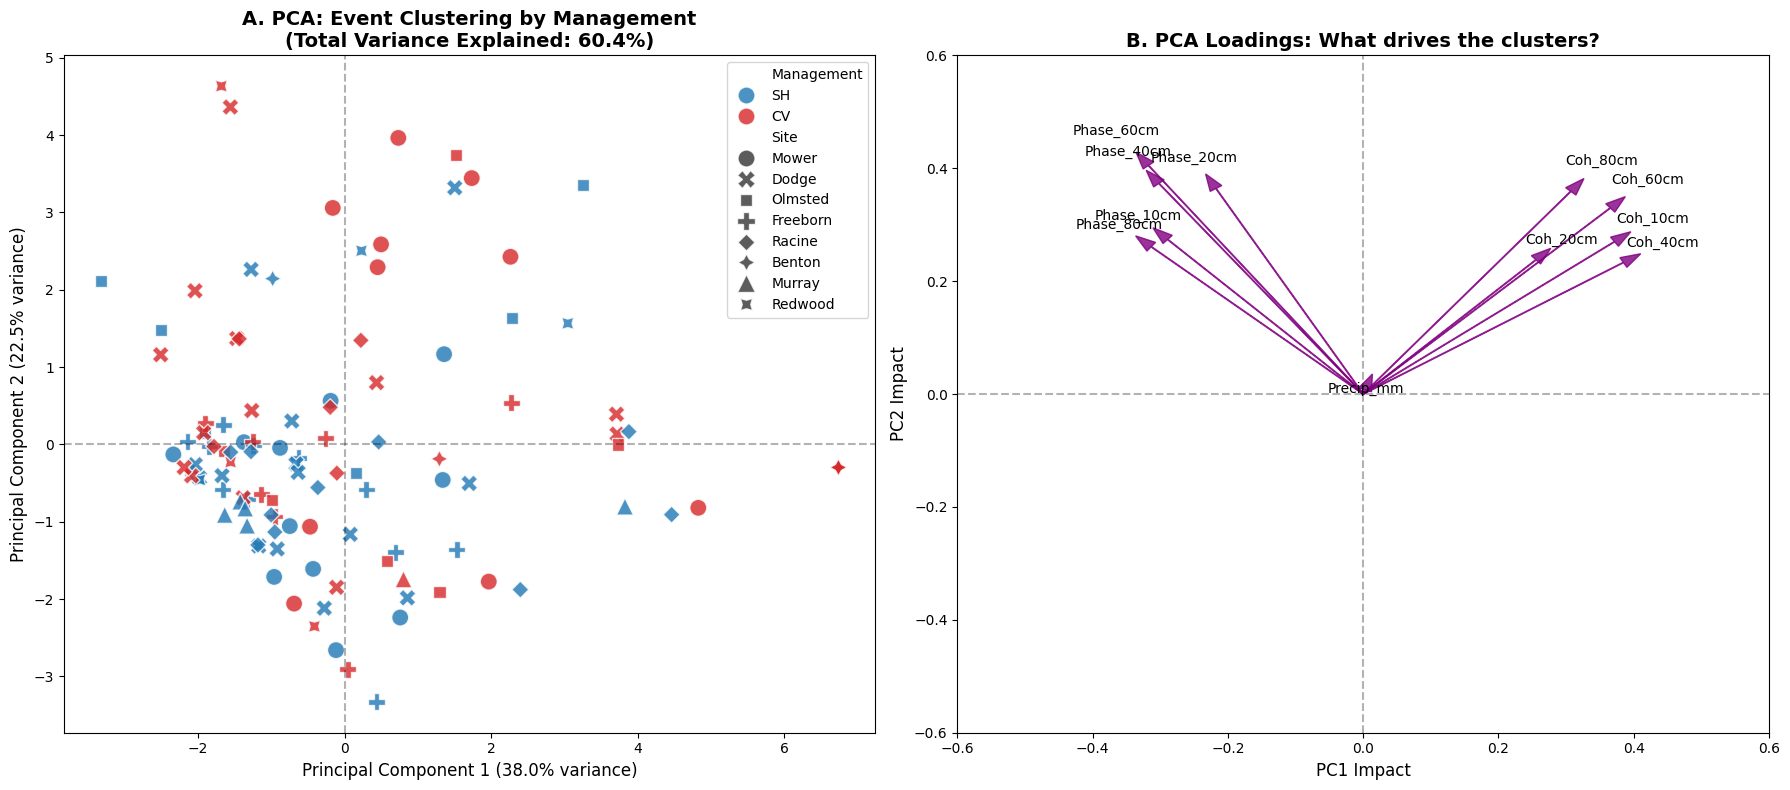

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# 1. LOAD DATA
file_path = '/content/drive/MyDrive/Preferential-Flow/Wavelet_Metrics/Wavelet_True_Coherence_Metrics.csv'

if not os.path.exists(file_path):
    print(f"❌ Could not find the file at {file_path}")
else:
    df_metrics = pd.read_csv(file_path)

    # 2. PIVOT THE DATA (Long to Wide)
    # We want one row per event, and columns for Coherence and Phase Shift at every depth.
    df_pivot = df_metrics.pivot_table(
        index=['Farm', 'State', 'Site', 'Management', 'Rain_Date', 'Precip_mm'],
        columns='Comparison',
        values=['Coherence_Score', 'Phase_Shift_Rad']
    ).reset_index()

    # Flatten the multi-level column names created by the pivot
    df_pivot.columns = ['_'.join(col).strip('_') for col in df_pivot.columns.values]

    # Drop rows with NaNs (PCA cannot handle missing values!)
    df_clean = df_pivot.dropna().copy()
    print(f"✅ Data prepped for PCA. {len(df_clean)} complete events found.")

    # 3. PREPARE FEATURES FOR PCA
    # Select numerical feature columns: Precip_mm, plus all Coherence and Phase columns
    feature_cols = [col for col in df_clean.columns if 'Coherence' in col or 'Phase' in col or 'Precip' in col]
    X = df_clean[feature_cols]

    # Standardize the features (Crucial so Precip_mm doesn't overpower Coherence!)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 4. RUN PCA
    pca = PCA(n_components=2) # Compress down to 2 dimensions
    pcs = pca.fit_transform(X_scaled)

    df_clean['PC1'] = pcs[:, 0]
    df_clean['PC2'] = pcs[:, 1]

    # 5. VISUALIZATION
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Plot A: PCA Scatter Plot (The Clusters)
    # We use Management for Color, and Site for the marker shape
    sns.scatterplot(data=df_clean, x='PC1', y='PC2', hue='Management', style='Site',
                    s=150, palette=['#1f77b4', '#d62728'], alpha=0.8, ax=axes[0])

    pc1_var = pca.explained_variance_ratio_[0]
    pc2_var = pca.explained_variance_ratio_[1]

    axes[0].set_title(f'A. PCA: Event Clustering by Management\n(Total Variance Explained: {pc1_var + pc2_var:.1%})', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(f'Principal Component 1 ({pc1_var:.1%} variance)', fontsize=12)
    axes[0].set_ylabel(f'Principal Component 2 ({pc2_var:.1%} variance)', fontsize=12)
    axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.3)

    # Plot B: PCA Loadings (The Arrows)
    loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_cols)

    axes[1].set_xlim(-0.6, 0.6)
    axes[1].set_ylim(-0.6, 0.6)
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[1].axvline(0, color='black', linestyle='--', alpha=0.3)

    for i, feature in enumerate(feature_cols):
        # Shorten names so the graph isn't a mess
        clean_name = feature.replace('Coherence_Score_', 'Coh_').replace('Phase_Shift_Rad_', 'Phase_').replace('10cm_vs_', '')

        axes[1].arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1], head_width=0.02, head_length=0.03, color='purple', alpha=0.8)
        axes[1].text(loadings.iloc[i, 0] * 1.15, loadings.iloc[i, 1] * 1.15, clean_name, color='black', ha='center', va='center', fontsize=10)

    axes[1].set_title('B. PCA Loadings: What drives the clusters?', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('PC1 Impact', fontsize=12)
    axes[1].set_ylabel('PC2 Impact', fontsize=12)

    plt.tight_layout()
    plt.show()

#Site-specific PCA for wavelet metrics

✅ Prepped data. Found 8 unique sites. Generating individual PCAs...



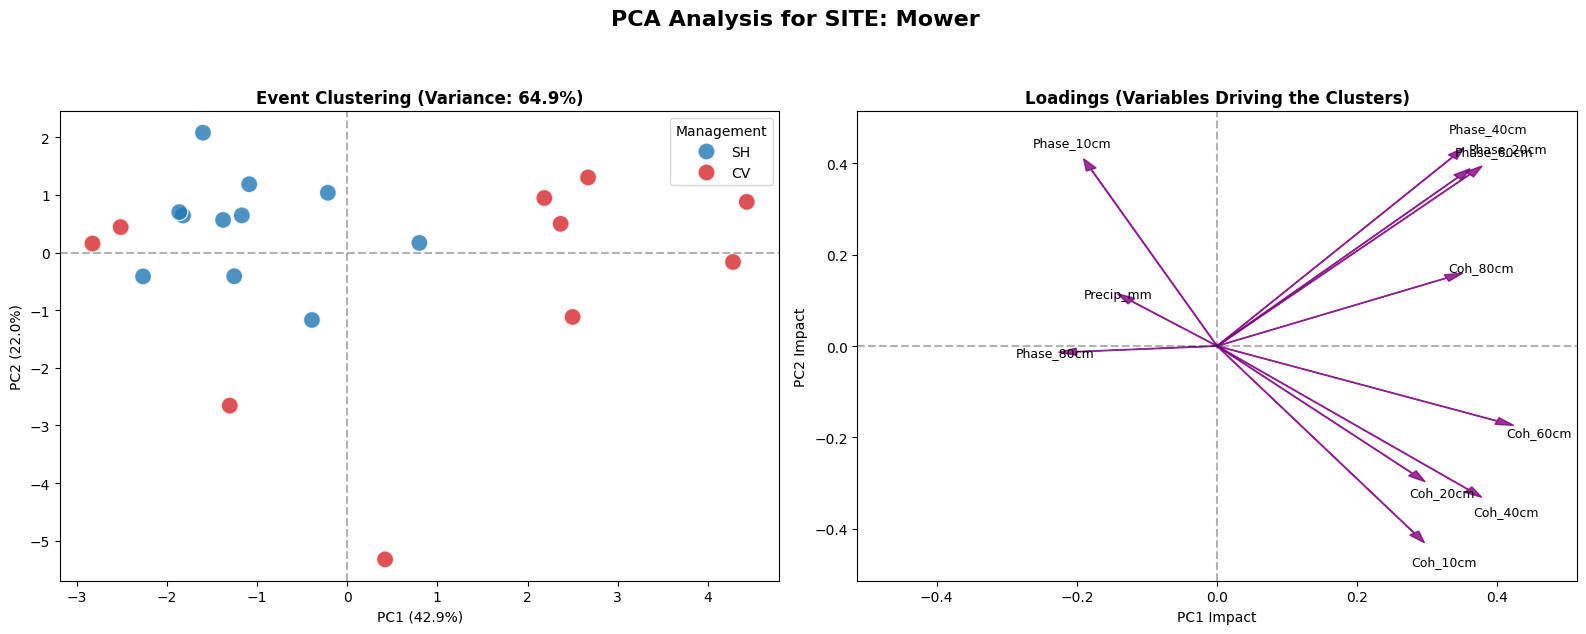

--------------------------------------------------------------------------------


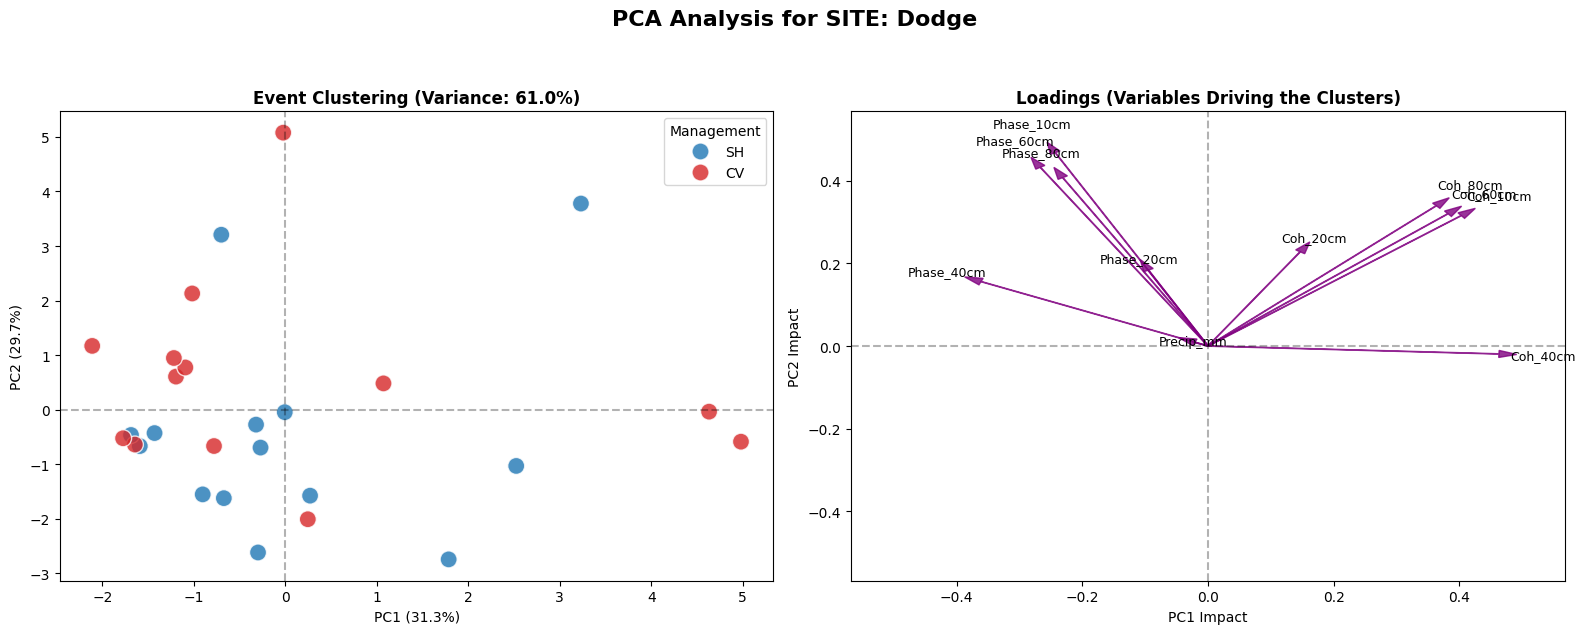

--------------------------------------------------------------------------------


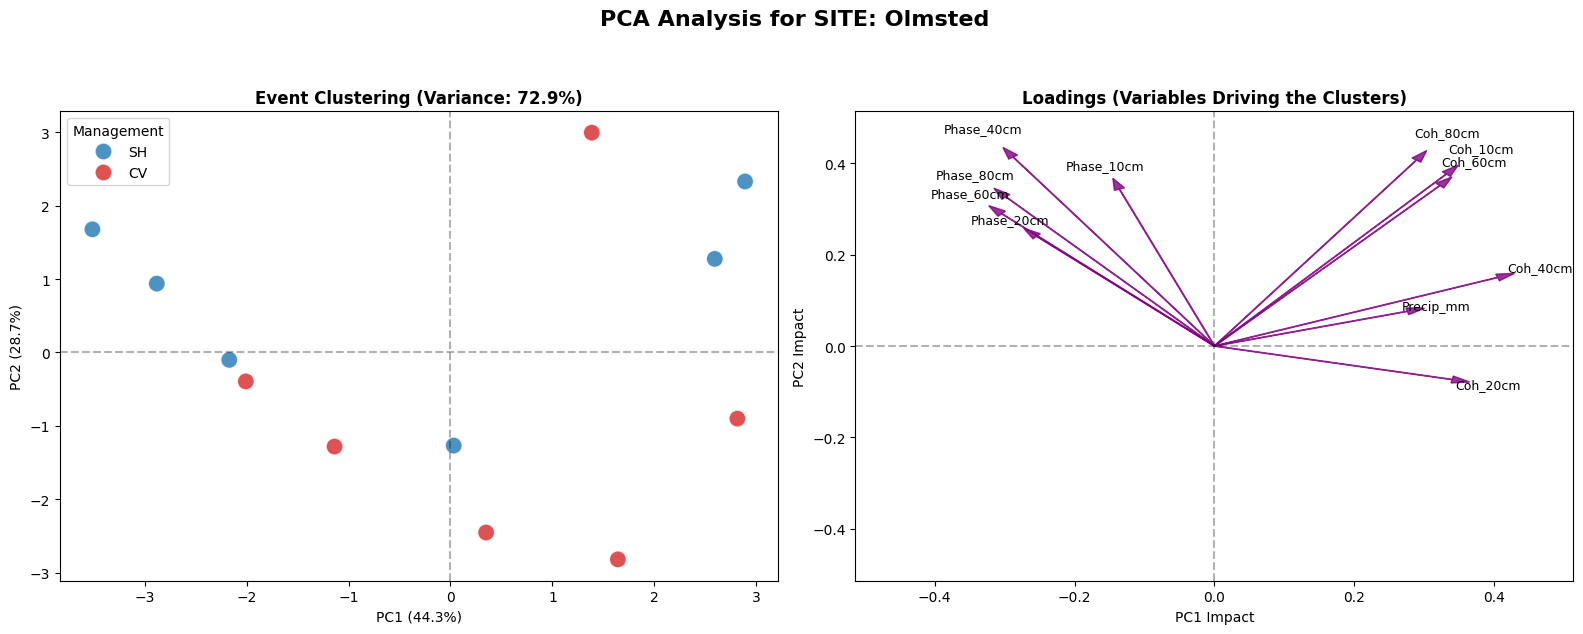

--------------------------------------------------------------------------------


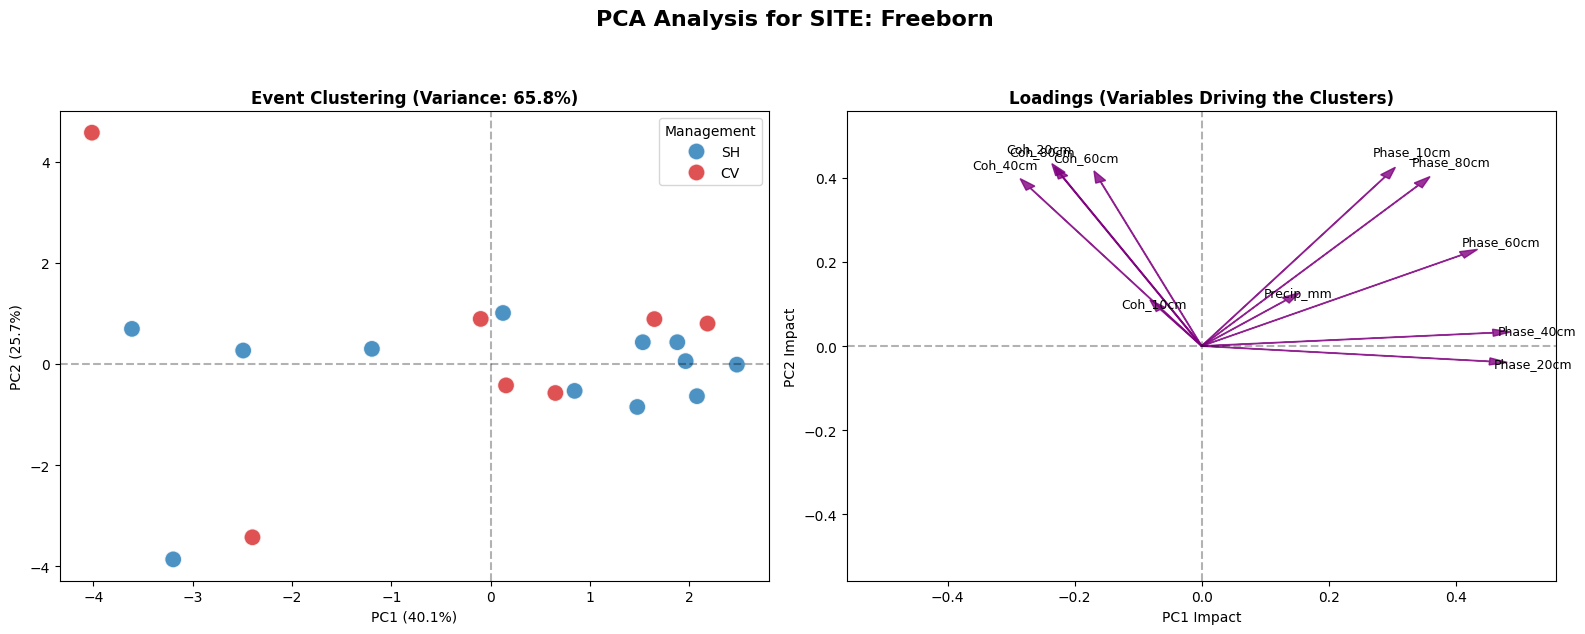

--------------------------------------------------------------------------------


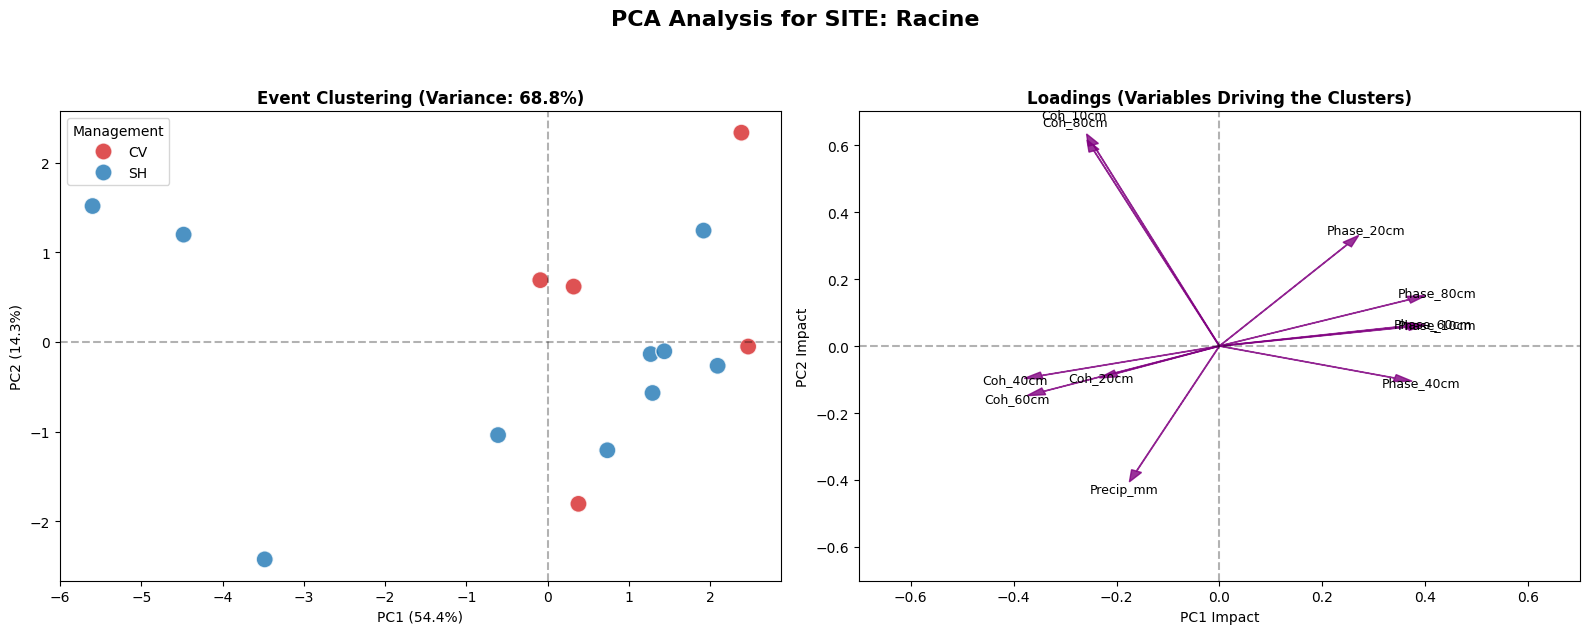

--------------------------------------------------------------------------------


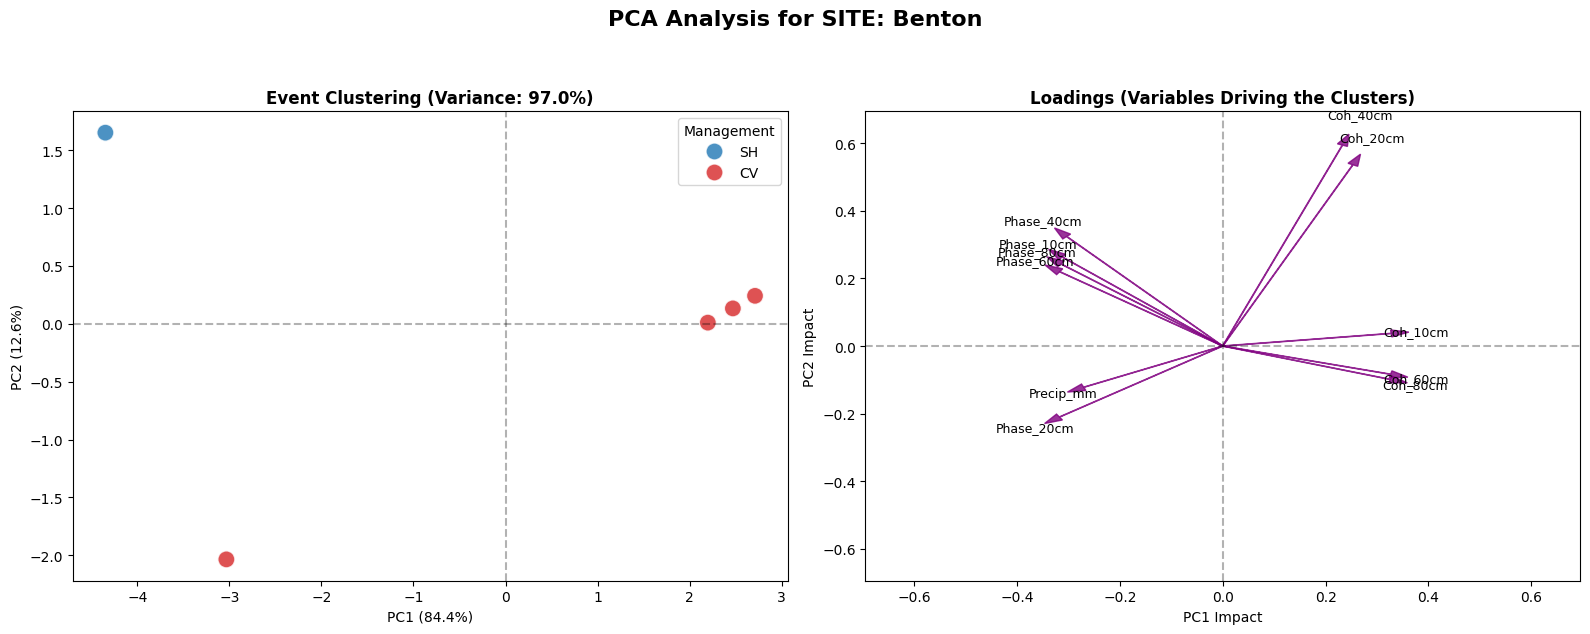

--------------------------------------------------------------------------------


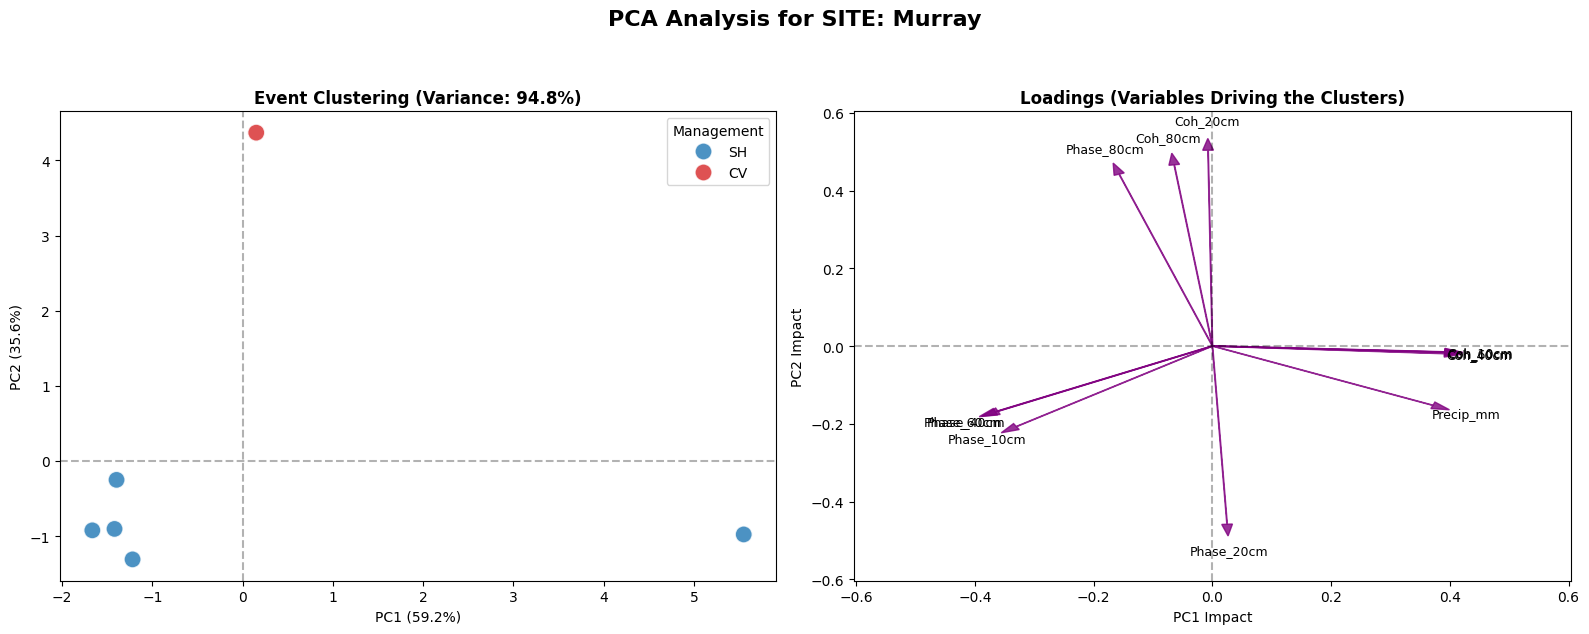

--------------------------------------------------------------------------------


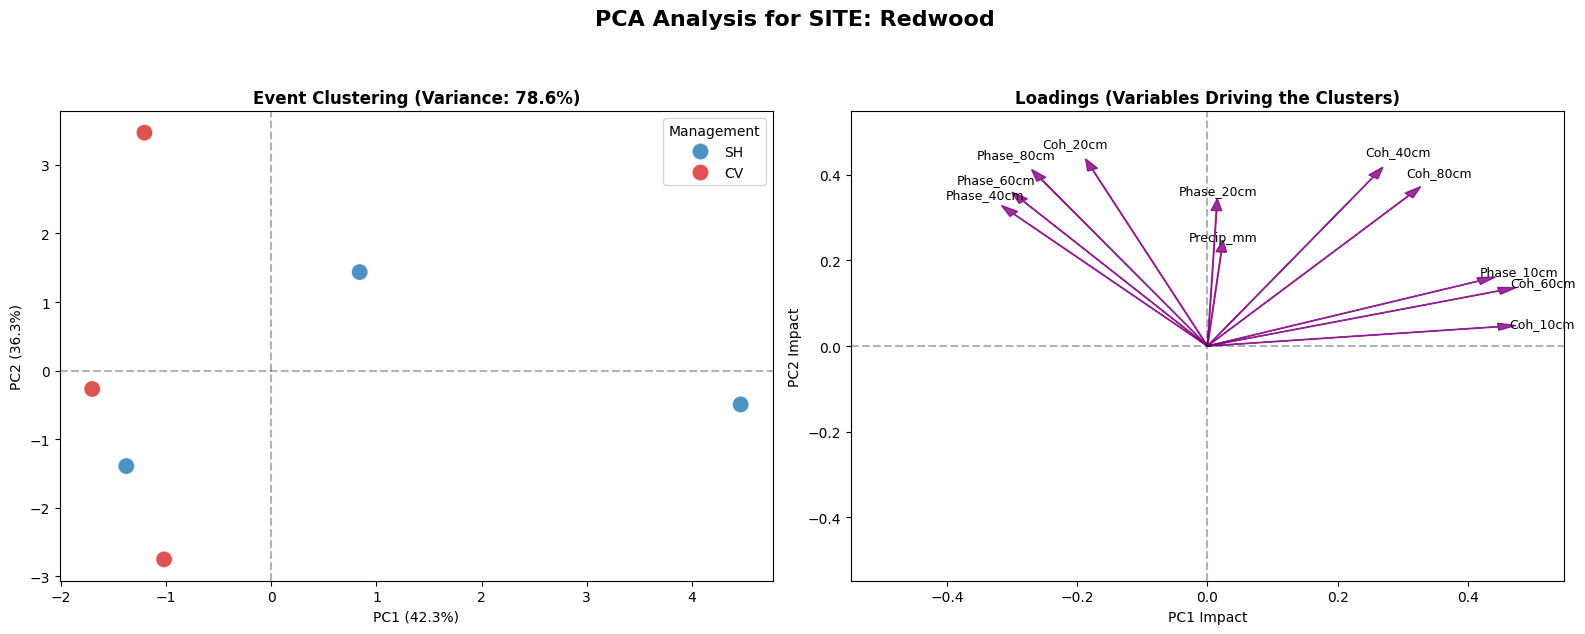

--------------------------------------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# 1. LOAD AND PREP DATA
file_path = '/content/drive/MyDrive/Preferential-Flow/Wavelet_Metrics/Wavelet_True_Coherence_Metrics.csv'

if not os.path.exists(file_path):
    print(f"❌ Could not find the file at {file_path}")
else:
    df_metrics = pd.read_csv(file_path)

    # Pivot to wide format
    df_pivot = df_metrics.pivot_table(
        index=['Farm', 'State', 'Site', 'Management', 'Rain_Date', 'Precip_mm'],
        columns='Comparison',
        values=['Coherence_Score', 'Phase_Shift_Rad']
    ).reset_index()

    df_pivot.columns = ['_'.join(col).strip('_') for col in df_pivot.columns.values]
    df_clean = df_pivot.dropna().copy()

    # Identify unique sites
    sites = df_clean['Site'].unique()
    print(f"✅ Prepped data. Found {len(sites)} unique sites. Generating individual PCAs...\n")

    # 2. LOOP THROUGH EACH SITE
    for site in sites:
        site_data = df_clean[df_clean['Site'] == site].copy()

        # We need a minimum number of events to run a meaningful PCA
        if len(site_data) < 4:
            print(f"⏭️ Skipping Site {site}: Not enough complete storm events ({len(site_data)}).")
            continue

        feature_cols = [col for col in site_data.columns if 'Coherence' in col or 'Phase' in col or 'Precip' in col]
        X = site_data[feature_cols]

        # Standardize the local site data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Run PCA
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(X_scaled)

        site_data['PC1'] = pcs[:, 0]
        site_data['PC2'] = pcs[:, 1]

        pc1_var = pca.explained_variance_ratio_[0]
        pc2_var = pca.explained_variance_ratio_[1]

        # 3. VISUALIZATION PER SITE
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'PCA Analysis for SITE: {site}', fontsize=16, fontweight='black', y=1.05)

        # Plot A: Clusters
        # (Using a dictionary for palette ensures CV is always red, SH is always blue, even if one is missing)
        sns.scatterplot(data=site_data, x='PC1', y='PC2', hue='Management',
                        s=150, palette={'CV': '#d62728', 'SH': '#1f77b4'}, alpha=0.8, ax=axes[0])

        axes[0].set_title(f'Event Clustering (Variance: {pc1_var + pc2_var:.1%})', fontsize=12, fontweight='bold')
        axes[0].set_xlabel(f'PC1 ({pc1_var:.1%})')
        axes[0].set_ylabel(f'PC2 ({pc2_var:.1%})')
        axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)
        axes[0].axvline(0, color='black', linestyle='--', alpha=0.3)

        # Plot B: Loadings
        loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_cols)

        # Dynamically set axes limits based on loading vector lengths
        max_load = np.max(np.abs(loadings.values)) + 0.1
        axes[1].set_xlim(-max_load, max_load)
        axes[1].set_ylim(-max_load, max_load)
        axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
        axes[1].axvline(0, color='black', linestyle='--', alpha=0.3)

        for i, feature in enumerate(feature_cols):
            clean_name = feature.replace('Coherence_Score_', 'Coh_').replace('Phase_Shift_Rad_', 'Phase_').replace('10cm_vs_', '')
            axes[1].arrow(0, 0, loadings.iloc[i, 0], loadings.iloc[i, 1], head_width=max_load*0.03, head_length=max_load*0.05, color='purple', alpha=0.8)
            axes[1].text(loadings.iloc[i, 0] * 1.15, loadings.iloc[i, 1] * 1.15, clean_name, color='black', ha='center', va='center', fontsize=9)

        axes[1].set_title('Loadings (Variables Driving the Clusters)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('PC1 Impact')
        axes[1].set_ylabel('PC2 Impact')

        plt.tight_layout()
        plt.show()
        print("-" * 80) # Divider between sites

#Depth of water movement

📊 PROFILE PERFORMANCE SUMMARY (CV vs SH):
           Max_Penetration_Depth_cm               Total_Profile_Gain_mm  \
                               mean median    std                  mean   
Management                                                                
CV                            62.55   80.0  37.79                 25.69   
SH                            55.48   60.0  34.58                 20.96   

                          
           median    std  
Management                
CV          20.14  25.33  
SH          11.54  23.59  
------------------------------------------------------------
📈 Mann-Whitney U Test for Max_Penetration_Depth_cm:
   CV Mean: 62.55 | SH Mean: 55.48
   U-statistic: 1639.00, p-value: 0.2581
   Result: No statistically significant difference.
------------------------------------------------------------
📈 Mann-Whitney U Test for Total_Profile_Gain_mm:
   CV Mean: 25.69 | SH Mean: 20.96
   U-statistic: 1595.50, p-value: 0.3982
   Result: No statis

/tmp/ipykernel_541/2404482840.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile, x='Management', y='Max_Penetration_Depth_cm', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_541/2404482840.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile, x='Management', y='Total_Profile_Gain_mm', ax=axes[1], palette=['#2ecc71', '#e74c3c'])


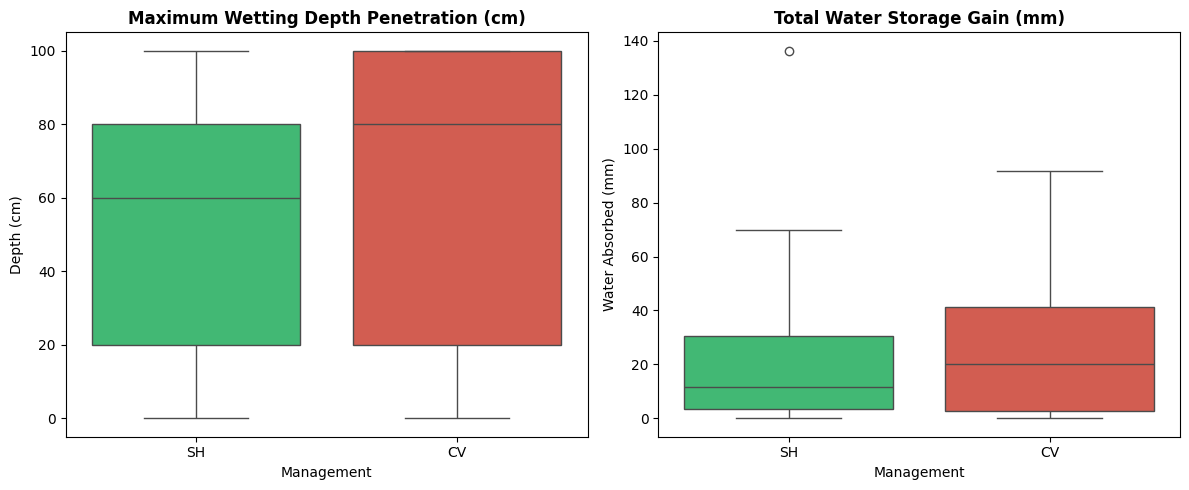

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_p_file_path = '/content/drive/MyDrive/Preferential-Flow/Cleaned_Data/df_p_cleaned.csv'
df_p = pd.read_csv(df_p_file_path)

df_m_file_path = '/content/drive/MyDrive/Preferential-Flow/Cleaned_Data/df_m_cleaned.csv'
df_m = pd.read_csv(df_m_file_path)

# ---------------------------------------------------------
# 1. PREPROCESS DATES & FILTER HEAVY RAIN
# ---------------------------------------------------------
# Ensure Date columns are explicitly converted to datetime
df_p['Date'] = pd.to_datetime(df_p['Date'], errors='coerce')
df_m['Date'] = pd.to_datetime(df_m['Date'], errors='coerce')

rain_threshold = 25.0
heavy_rain = df_p[df_p['Rainfall_mm'] >= rain_threshold].dropna(subset=['Date']).copy()

# Layer thickness in mm for total water volume calculation (0-100cm profile)
depth_weights = {'10_M': 100, '20_M': 100, '40_M': 200, '60_M': 200, '80_M': 200, '100_M': 200}

profile_results = []

# ---------------------------------------------------------
# 2. CALCULATE MAX DEPTH & TOTAL WATER GAIN
# ---------------------------------------------------------
for index, event in heavy_rain.iterrows():
    f_name = event['F_name']
    state = event['State']
    site_num = str(event['Site'])

    # Cast to Timestamp to allow Timedelta operations
    rain_date = pd.to_datetime(event['Date'])

    window_start = rain_date - pd.Timedelta(hours=24)
    window_end = rain_date + pd.Timedelta(hours=24)

    sub_m = df_m[(df_m['F_name'] == f_name) &
                 (df_m['State'] == state) &
                 (df_m['Site'].astype(str) == site_num) &
                 (df_m['Date'] >= window_start) &
                 (df_m['Date'] <= window_end)]

    if sub_m.empty:
        continue

    for mgmt in sub_m['Management'].unique():
        u_data = sub_m[sub_m['Management'] == mgmt].set_index('Date').resample('15min').mean(numeric_only=True).interpolate(method='time')

        pre_rain = u_data[u_data.index < rain_date]
        if pre_rain.empty:
            continue

        max_depth_cm = 0
        total_storage_gain_mm = 0

        for col, layer_thickness in depth_weights.items():
            if col not in u_data.columns:
                continue

            baseline = pre_rain[col].mean()
            peak = u_data.loc[u_data.index >= rain_date, col].max()
            delta_vwc = peak - baseline

            # Sensor response threshold (>= 0.005 m³/m³)
            if delta_vwc >= 0.005:
                depth_int = int(col.split('_')[0])
                if depth_int > max_depth_cm:
                    max_depth_cm = depth_int
                total_storage_gain_mm += (delta_vwc * layer_thickness)

        profile_results.append({
            'Farm': f_name,
            'Site': site_num,
            'Management': mgmt,
            'Rain_Date': rain_date,
            'Precip_mm': event['Rainfall_mm'],
            'Max_Penetration_Depth_cm': max_depth_cm,
            'Total_Profile_Gain_mm': total_storage_gain_mm
        })

df_profile = pd.DataFrame(profile_results)

# ---------------------------------------------------------
# 3. STATISTICAL COMPARISON & VISUALIZATION
# ---------------------------------------------------------
if not df_profile.empty:
    print("📊 PROFILE PERFORMANCE SUMMARY (CV vs SH):")
    summary_metrics = df_profile.groupby('Management')[['Max_Penetration_Depth_cm', 'Total_Profile_Gain_mm']].agg(['mean', 'median', 'std']).round(2)
    print(summary_metrics)
    print("-" * 60)

    for col in ['Max_Penetration_Depth_cm', 'Total_Profile_Gain_mm']:
        cv_vals = df_profile[df_profile['Management'] == 'CV'][col].dropna()
        sh_vals = df_profile[df_profile['Management'] == 'SH'][col].dropna()

        if len(cv_vals) > 0 and len(sh_vals) > 0:
            u_stat, p_val = stats.mannwhitneyu(cv_vals, sh_vals, alternative='two-sided')
            print(f"📈 Mann-Whitney U Test for {col}:")
            print(f"   CV Mean: {cv_vals.mean():.2f} | SH Mean: {sh_vals.mean():.2f}")
            print(f"   U-statistic: {u_stat:.2f}, p-value: {p_val:.4f}")
            if p_val < 0.05:
                print("   ✨ Result: Statistically Significant (p < 0.05)!")
            else:
                print("   Result: No statistically significant difference.")
            print("-" * 60)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.boxplot(data=df_profile, x='Management', y='Max_Penetration_Depth_cm', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
    axes[0].set_title('Maximum Wetting Depth Penetration (cm)', fontweight='bold')
    axes[0].set_ylabel('Depth (cm)')

    sns.boxplot(data=df_profile, x='Management', y='Total_Profile_Gain_mm', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
    axes[1].set_title('Total Water Storage Gain (mm)', fontweight='bold')
    axes[1].set_ylabel('Water Absorbed (mm)')

    plt.tight_layout()
    plt.show()
else:
    print("No profile events detected. Verify date and site alignment.")

📊 STATISTICAL VERDICT FOR MAX PENETRATION DEPTH:
CV Mean Depth : 50.08 cm (Median: 40.0 cm)
SH Mean Depth : 44.00 cm (Median: 40.0 cm)
Mann-Whitney U Test : U = 325305.50, p-value = 0.0033
Welch's t-test     : t = 3.04, p-value = 0.0024
✨ RESULT: Statistically Significant (p < 0.05)! CV and SH differ in wetting depth.
------------------------------------------------------------
📊 FEATURE IMPORTANCE: WHAT DRIVES MAX WETTING DEPTH?
                Feature  Importance_Pct
              Precip_mm       53.260161
                     OM       31.311305
         Texture_medium        5.176818
          Management_CV        4.402116
          Management_SH        3.399005
Texture_moderately fine        1.677655
         Texture_coarse        0.772942


/tmp/ipykernel_541/231237205.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_depth, x='Importance_Pct', y='Feature', ax=axes[0], palette='crest')


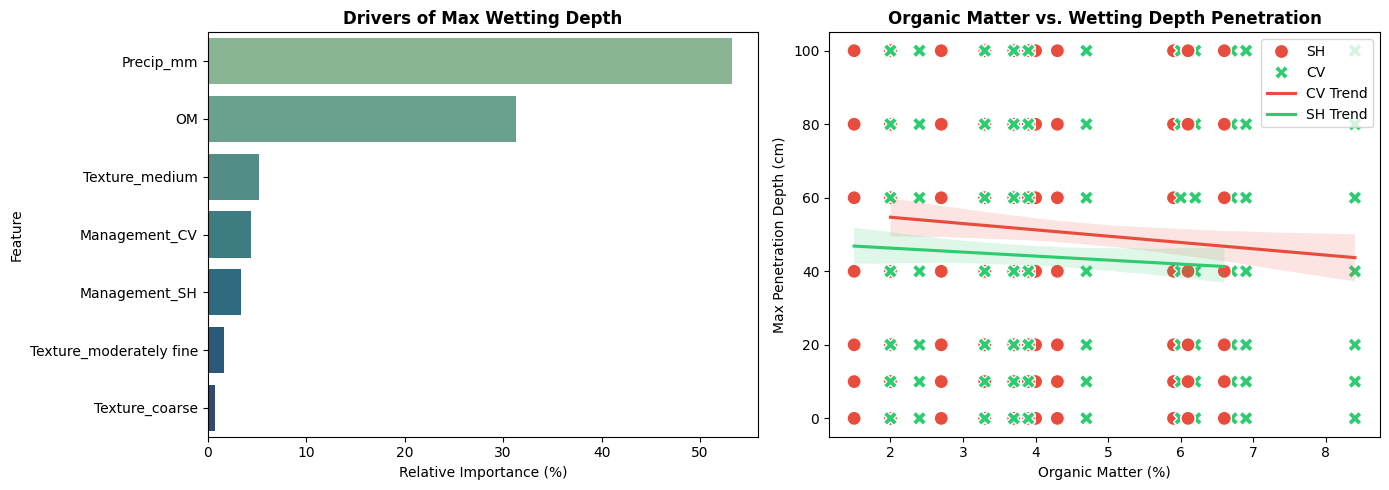

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor

file_path = '/content/drive/MyDrive/Preferential-Flow/Individual_Events/Nonsequential_Flow_Summary.csv'
df_flow_summary = pd.read_csv(file_path)

# ---------------------------------------------------------
# 1. STATISTICAL SIGNIFICANCE TEST (CV vs SH)
# ---------------------------------------------------------
cv_depths = df_profile[df_profile['Management'] == 'CV']['Max_Penetration_Depth_cm'].dropna()
sh_depths = df_profile[df_profile['Management'] == 'SH']['Max_Penetration_Depth_cm'].dropna()

u_stat, p_val_u = stats.mannwhitneyu(cv_depths, sh_depths, alternative='two-sided')
t_stat, p_val_t = stats.ttest_ind(cv_depths, sh_depths, equal_var=False)

print("📊 STATISTICAL VERDICT FOR MAX PENETRATION DEPTH:")
print(f"CV Mean Depth : {cv_depths.mean():.2f} cm (Median: {cv_depths.median():.1f} cm)")
print(f"SH Mean Depth : {sh_depths.mean():.2f} cm (Median: {sh_depths.median():.1f} cm)")
print(f"Mann-Whitney U Test : U = {u_stat:.2f}, p-value = {p_val_u:.4f}")
print(f"Welch's t-test     : t = {t_stat:.2f}, p-value = {p_val_t:.4f}")

if p_val_u < 0.05:
    print("✨ RESULT: Statistically Significant (p < 0.05)! CV and SH differ in wetting depth.")
else:
    print("RESULT: No statistically significant difference in penetration depth (p >= 0.05).")
print("-" * 60)

# ---------------------------------------------------------
# 2. MERGE SITE DESCRIPTORS FOR DRIVER MODELING
# ---------------------------------------------------------
site_meta = df_flow_summary[['Farm', 'Site', 'OM', 'Texture']].drop_duplicates()
df_profile_meta = pd.merge(df_profile, site_meta, on=['Farm', 'Site'], how='inner')

# ---------------------------------------------------------
# 3. RANDOM FOREST REGRESSOR: DRIVERS OF WETTING DEPTH
# ---------------------------------------------------------
X_depth = pd.get_dummies(df_profile_meta[['Precip_mm', 'OM', 'Texture', 'Management']], drop_first=False)
y_depth = df_profile_meta['Max_Penetration_Depth_cm']

rf_depth = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=5)
rf_depth.fit(X_depth, y_depth)

imp_depth = pd.DataFrame({
    'Feature': X_depth.columns,
    'Importance_Pct': rf_depth.feature_importances_ * 100
}).sort_values(by='Importance_Pct', ascending=False)

print("📊 FEATURE IMPORTANCE: WHAT DRIVES MAX WETTING DEPTH?")
print(imp_depth.to_string(index=False))

# ---------------------------------------------------------
# 4. VISUALIZING DRIVERS & OM INTERACTION
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature Importances
sns.barplot(data=imp_depth, x='Importance_Pct', y='Feature', ax=axes[0], palette='crest')
axes[0].set_title('Drivers of Max Wetting Depth', fontweight='bold')
axes[0].set_xlabel('Relative Importance (%)')

# Plot 2: Organic Matter vs Max Depth by Management
sns.scatterplot(
    data=df_profile_meta, x='OM', y='Max_Penetration_Depth_cm',
    hue='Management', style='Management', s=100, ax=axes[1], palette=['#2ecc71', '#e74c3c']
)
sns.regplot(data=df_profile_meta[df_profile_meta['Management']=='CV'], x='OM', y='Max_Penetration_Depth_cm', scatter=False, ax=axes[1], color='#e74c3c', label='CV Trend')
sns.regplot(data=df_profile_meta[df_profile_meta['Management']=='SH'], x='OM', y='Max_Penetration_Depth_cm', scatter=False, ax=axes[1], color='#2ecc71', label='SH Trend')

axes[1].set_title('Organic Matter vs. Wetting Depth Penetration', fontweight='bold')
axes[1].set_xlabel('Organic Matter (%)')
axes[1].set_ylabel('Max Penetration Depth (cm)')
axes[1].legend()

plt.tight_layout()
plt.show()

###Baseline water content before events

📊 BASELINE SOIL MOISTURE SUMMARY (CV vs SH):
           Profile_Baseline_VWC                 Topsoil_Baseline_VWC          \
                           mean  median     std                 mean  median   
Management                                                                     
CV                       0.2894  0.3073  0.0883               0.2685  0.2634   
SH                       0.2887  0.2996  0.0874               0.2442  0.2432   

                    
               std  
Management          
CV          0.0998  
SH          0.0988  
------------------------------------------------------------
📈 Mann-Whitney U Test for Profile_Baseline_VWC:
   CV Mean: 0.2894 m³/m³ | SH Mean: 0.2887 m³/m³
   U-statistic: 309314.50, p-value: 0.2844
   Result: No statistically significant difference.
------------------------------------------------------------
📈 Mann-Whitney U Test for Topsoil_Baseline_VWC:
   CV Mean: 0.2685 m³/m³ | SH Mean: 0.2442 m³/m³
   U-statistic: 339074.00, p-value: 0.

/tmp/ipykernel_541/3943384612.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_baseline, x='Management', y='Topsoil_Baseline_VWC', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_541/3943384612.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_baseline, x='Management', y='Profile_Baseline_VWC', ax=axes[1], palette=['#e74c3c', '#2ecc71'])


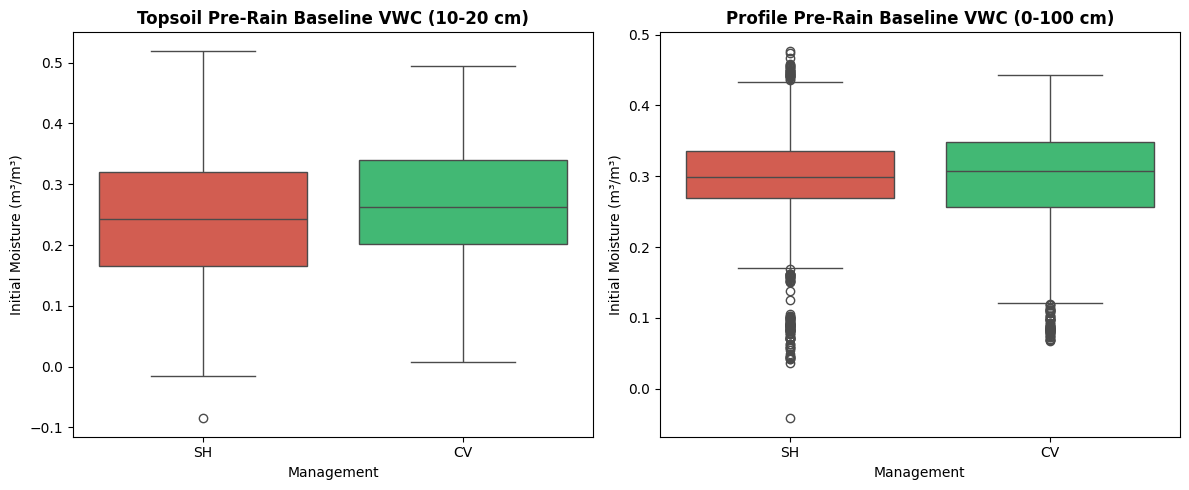

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---------------------------------------------------------
# 1. PREPROCESS & EXTRACT 24-HOUR PRE-RAIN BASELINE VWC
# ---------------------------------------------------------
df_p['Date'] = pd.to_datetime(df_p['Date'], errors='coerce')
df_m['Date'] = pd.to_datetime(df_m['Date'], errors='coerce')

depth_cols = ['10_M', '20_M', '40_M', '60_M', '80_M', '100_M']
rain_events = df_p[df_p['Rainfall_mm'] >= 1.0].dropna(subset=['Date']).copy()

baseline_results = []

for index, event in rain_events.iterrows():
    f_name = event['F_name']
    state = event['State']
    site_num = str(event['Site'])
    rain_date = pd.to_datetime(event['Date'])

    # Pre-event window: 24 hours prior to rain onset
    window_start = rain_date - pd.Timedelta(hours=24)

    sub_m = df_m[(df_m['F_name'] == f_name) &
                 (df_m['State'] == state) &
                 (df_m['Site'].astype(str) == site_num) &
                 (df_m['Date'] >= window_start) &
                 (df_m['Date'] < rain_date)]

    if sub_m.empty:
        continue

    for mgmt in sub_m['Management'].unique():
        mgmt_data = sub_m[sub_m['Management'] == mgmt]

        avail_cols = [c for c in depth_cols if c in mgmt_data.columns]
        if not avail_cols:
            continue

        # Profile average (0-100 cm) and Topsoil average (10-20 cm)
        profile_baseline = mgmt_data[avail_cols].mean(numeric_only=True).mean()

        topsoil_cols = [c for c in ['10_M', '20_M'] if c in mgmt_data.columns]
        topsoil_baseline = mgmt_data[topsoil_cols].mean(numeric_only=True).mean() if topsoil_cols else np.nan

        baseline_results.append({
            'Farm': f_name,
            'Site': site_num,
            'Management': mgmt,
            'Rain_Date': rain_date,
            'Precip_mm': event['Rainfall_mm'],
            'Profile_Baseline_VWC': profile_baseline,
            'Topsoil_Baseline_VWC': topsoil_baseline
        })

df_baseline = pd.DataFrame(baseline_results)

# ---------------------------------------------------------
# 2. STATISTICAL COMPARISON (CV vs SH)
# ---------------------------------------------------------
print("📊 BASELINE SOIL MOISTURE SUMMARY (CV vs SH):")
print(df_baseline.groupby('Management')[['Profile_Baseline_VWC', 'Topsoil_Baseline_VWC']].agg(['mean', 'median', 'std']).round(4))
print("-" * 60)

for col in ['Profile_Baseline_VWC', 'Topsoil_Baseline_VWC']:
    cv_vals = df_baseline[df_baseline['Management'] == 'CV'][col].dropna()
    sh_vals = df_baseline[df_baseline['Management'] == 'SH'][col].dropna()

    if len(cv_vals) > 0 and len(sh_vals) > 0:
        u_stat, p_val = stats.mannwhitneyu(cv_vals, sh_vals, alternative='two-sided')
        print(f"📈 Mann-Whitney U Test for {col}:")
        print(f"   CV Mean: {cv_vals.mean():.4f} m³/m³ | SH Mean: {sh_vals.mean():.4f} m³/m³")
        print(f"   U-statistic: {u_stat:.2f}, p-value: {p_val:.4f}")
        if p_val < 0.05:
            print("   ✨ Result: Statistically Significant (p < 0.05)!")
        else:
            print("   Result: No statistically significant difference.")
        print("-" * 60)

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_baseline, x='Management', y='Topsoil_Baseline_VWC', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Topsoil Pre-Rain Baseline VWC (10-20 cm)', fontweight='bold')
axes[0].set_ylabel('Initial Moisture (m³/m³)')

sns.boxplot(data=df_baseline, x='Management', y='Profile_Baseline_VWC', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Profile Pre-Rain Baseline VWC (0-100 cm)', fontweight='bold')
axes[1].set_ylabel('Initial Moisture (m³/m³)')

plt.tight_layout()
plt.show()

#Site characteristics

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# ---------------------------------------------------------
# 1. EVENT COUNT BREAKDOWN (>1mm vs >25mm)
# ---------------------------------------------------------
# Filter profiles by rainfall thresholds
events_all = df_profile[df_profile['Precip_mm'] >= 1.0]
events_heavy = df_profile[df_profile['Precip_mm'] >= 25.0]

print("📊 EVENT DISTRIBUTION BY MANAGEMENT:")
print(f"Total Events (>1 mm)   : {len(events_all)} (CV: {sum(events_all['Management']=='CV')}, SH: {sum(events_all['Management']=='SH')})")
print(f"Heavy Events (>25 mm)  : {len(events_heavy)} (CV: {sum(events_heavy['Management']=='CV')}, SH: {sum(events_heavy['Management']=='SH')})")
print("-" * 60)

# ---------------------------------------------------------
# 2. ORGANIC MATTER (OM) COMPARISON
# ---------------------------------------------------------
site_om = df_flow_summary.groupby(['Farm', 'Site', 'Management'])['OM'].mean().reset_index()

cv_om = site_om[site_om['Management'] == 'CV']['OM'].dropna()
sh_om = site_om[site_om['Management'] == 'SH']['OM'].dropna()

print("🌱 ORGANIC MATTER SUMMARY (%):")
print(f"CV OM - Mean: {cv_om.mean():.2f}%, Median: {cv_om.median():.2f}%")
print(f"SH OM - Mean: {sh_om.mean():.2f}%, Median: {sh_om.median():.2f}%")

u_om, p_om = stats.mannwhitneyu(cv_om, sh_om, alternative='two-sided')
print(f"Mann-Whitney U Test for OM: U = {u_om:.2f}, p-value = {p_om:.4f}")
if p_om < 0.05:
    print("✨ SH has statistically significantly higher OM than CV!")
else:
    print("No statistically significant difference in OM between treatments.")
print("-" * 60)

# ---------------------------------------------------------
# 3. TEXTURE DISTRIBUTION COMPARISON
# ---------------------------------------------------------
print("🪨 SOIL TEXTURE DISTRIBUTION (Site Count):")
texture_counts = pd.crosstab(df_flow_summary['Management'], df_flow_summary['Texture'])
print(texture_counts)
print("-" * 60)

# ---------------------------------------------------------
# 4. PRECIPITATION DISTRIBUTION EQUALITY
# ---------------------------------------------------------
cv_precip = events_all[events_all['Management'] == 'CV']['Precip_mm']
sh_precip = events_all[events_all['Management'] == 'SH']['Precip_mm']

u_p, p_precip = stats.mannwhitneyu(cv_precip, sh_precip, alternative='two-sided')
print("🌧️ PRECIPITATION EVENT EQUALITY CHECK:")
print(f"CV Mean Rain: {cv_precip.mean():.2f} mm | SH Mean Rain: {sh_precip.mean():.2f} mm")
print(f"p-value for Rain Magnitude Difference: {p_precip:.4f}")
if p_precip >= 0.05:
    print("✅ Rain events were equally distributed in magnitude between CV and SH.")

📊 EVENT DISTRIBUTION BY MANAGEMENT:
Total Events (>1 mm)   : 1553 (CV: 720, SH: 833)
Heavy Events (>25 mm)  : 109 (CV: 47, SH: 62)
------------------------------------------------------------
🌱 ORGANIC MATTER SUMMARY (%):
CV OM - Mean: 4.79%, Median: 4.30%
SH OM - Mean: 3.98%, Median: 3.90%
Mann-Whitney U Test for OM: U = 94.00, p-value = 0.3978
No statistically significant difference in OM between treatments.
------------------------------------------------------------
🪨 SOIL TEXTURE DISTRIBUTION (Site Count):
Texture     coarse  medium  moderately fine
Management                                 
CV               1      34                5
SH               1      47                3
------------------------------------------------------------
🌧️ PRECIPITATION EVENT EQUALITY CHECK:
CV Mean Rain: 8.72 mm | SH Mean Rain: 9.05 mm
p-value for Rain Magnitude Difference: 0.6707
✅ Rain events were equally distributed in magnitude between CV and SH.


In [ ]:
import pandas as pd
from scipy import stats

# Extract rainfall events for both management practices (>1 mm dataset)
cv_precip = df_profile[df_profile['Management'] == 'CV']['Precip_mm'].dropna()
sh_precip = df_profile[df_profile['Management'] == 'SH']['Precip_mm'].dropna()

# Calculate descriptive statistics
precip_summary = pd.DataFrame({
    'Management': ['CV', 'SH'],
    'Count': [len(cv_precip), len(sh_precip)],
    'Mean_mm': [cv_precip.mean(), sh_precip.mean()],
    'Median_mm': [cv_precip.median(), sh_precip.median()],
    'IQR_mm': [cv_precip.quantile(0.75) - cv_precip.quantile(0.25),
               sh_precip.quantile(0.75) - sh_precip.quantile(0.25)],
    'Max_mm': [cv_precip.max(), sh_precip.max()]
}).round(2)

# Mann-Whitney U test for non-parametric distribution comparison
u_stat, p_val = stats.mannwhitneyu(cv_precip, sh_precip, alternative='two-sided')

print("🌧️ PRECIPITATION DISTRIBUTION METRICS:")
print(precip_summary.to_string(index=False))
print("-" * 60)
print(f"Mann-Whitney U Test: U = {u_stat:.2f}, p-value = {p_val:.4f}")

if p_val >= 0.05:
    print("✅ VERDICT: Median storm magnitudes are statistically equivalent across CV and SH.")
else:
    print("⚠️ VERDICT: Storm event distributions differ significantly between CV and SH.")

🌧️ PRECIPITATION DISTRIBUTION METRICS:
Management  Count  Mean_mm  Median_mm  IQR_mm  Max_mm
        CV    720     8.72        4.8     7.7   205.2
        SH    833     9.05        4.9     8.1   205.2
------------------------------------------------------------
Mann-Whitney U Test: U = 296132.50, p-value = 0.6707
✅ VERDICT: Median storm magnitudes are statistically equivalent across CV and SH.


#Moisture range per depth, texture and management

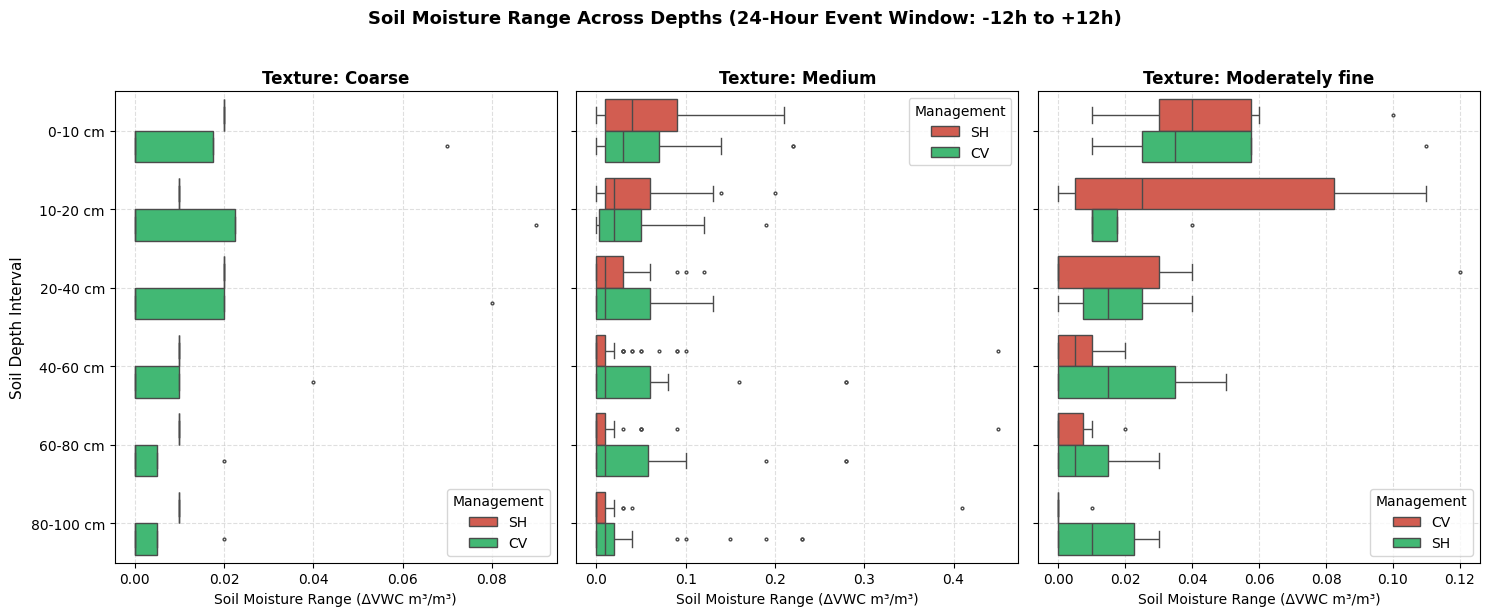

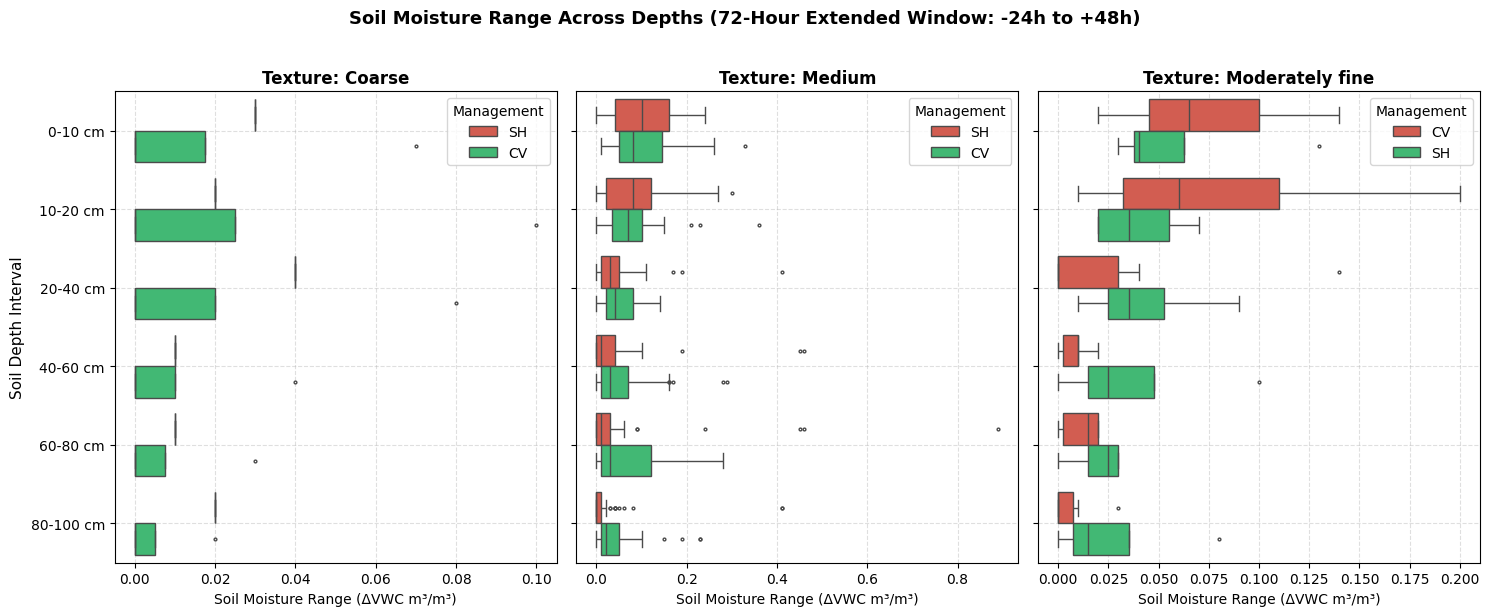

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Depth mappings and surface-to-deep vertical order
depth_map = {
    '10_M': '0-10 cm',
    '20_M': '10-20 cm',
    '40_M': '20-40 cm',
    '60_M': '40-60 cm',
    '80_M': '60-80 cm',
    '100_M': '80-100 cm'
}
depth_order = ['0-10 cm', '10-20 cm', '20-40 cm', '40-60 cm', '60-80 cm', '80-100 cm']

def extract_event_moisture_range_fast(df_m, df_p, hours_before=12, hours_after=12, rain_min=25.0):
    """
    Optimized extraction of soil moisture ranges per depth layer using pre-grouped site lookups.
    """
    # Ensure datetime format and string alignment
    df_p = df_p.copy()
    df_m = df_m.copy()

    df_p['Date'] = pd.to_datetime(df_p['Date'], errors='coerce')
    df_m['Date'] = pd.to_datetime(df_m['Date'], errors='coerce')

    df_p['Site'] = df_p['Site'].astype(str)
    df_m['Site'] = df_m['Site'].astype(str)

    # Filter precipitation events
    events = df_p[df_p['Rainfall_mm'] >= rain_min].dropna(subset=['Date']).copy()

    # Pre-group moisture dataframe by site key for fast O(1) dictionary lookups
    site_groups = {key: group for key, group in df_m.groupby(['F_name', 'State', 'Site'])}

    records = []

    for _, event in events.iterrows():
        f_name = event['F_name']
        state = event['State']
        site_num = event['Site']
        rain_date = event['Date']
        texture_val = event['Texture'] if 'Texture' in event else 'Unknown'

        site_key = (f_name, state, site_num)
        if site_key not in site_groups:
            continue

        sub_site = site_groups[site_key]

        t_start = rain_date - pd.Timedelta(hours=hours_before)
        t_end = rain_date + pd.Timedelta(hours=hours_after)

        # Fast datetime slice
        sub_window = sub_site[(sub_site['Date'] >= t_start) & (sub_site['Date'] <= t_end)]
        if sub_window.empty:
            continue

        for mgmt in sub_window['Management'].unique():
            mgmt_sub = sub_window[sub_window['Management'] == mgmt]

            for col_code, label in depth_map.items():
                if col_code in mgmt_sub.columns:
                    vwc_vals = mgmt_sub[col_code].dropna()
                    if len(vwc_vals) > 0:
                        delta_vwc = vwc_vals.max() - vwc_vals.min()
                        records.append({
                            'Farm': f_name,
                            'Site': site_num,
                            'Management': mgmt,
                            'Texture': texture_val,
                            'Depth': label,
                            'Moisture_Range_VWC': delta_vwc,
                            'Event_Date': rain_date
                        })

    return pd.DataFrame(records)

# ---------------------------------------------------------
# RUN FAST EXTRACTION (24h and 72h Windows)
# ---------------------------------------------------------
df_range_24h = extract_event_moisture_range_fast(df_m, df_p, hours_before=12, hours_after=12)
df_range_72h = extract_event_moisture_range_fast(df_m, df_p, hours_before=24, hours_after=48)

# ---------------------------------------------------------
# PLOTTING FUNCTION
# ---------------------------------------------------------
def plot_texture_depth_boxplots(df_range, window_title):
    target_textures = ['coarse', 'medium', 'moderately fine']
    avail_textures = [t for t in target_textures if t in df_range['Texture'].dropna().unique()]

    if not avail_textures:
        print(f"No texture data found matching: {target_textures}")
        return

    fig, axes = plt.subplots(1, len(avail_textures), figsize=(5 * len(avail_textures), 6), sharey=True)
    if len(avail_textures) == 1:
        axes = [axes]

    for i, tex in enumerate(avail_textures):
        sub_tex = df_range[df_range['Texture'] == tex]

        sns.boxplot(
            data=sub_tex,
            x='Moisture_Range_VWC',
            y='Depth',
            hue='Management',
            order=depth_order,
            palette=['#e74c3c', '#2ecc71'],
            ax=axes[i],
            fliersize=2
        )
        axes[i].set_title(f'Texture: {str(tex).capitalize()}', fontweight='bold', fontsize=12)
        axes[i].set_xlabel('Soil Moisture Range (ΔVWC m³/m³)', fontsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.4)

        if i == 0:
            axes[i].set_ylabel('Soil Depth Interval', fontsize=11)
        else:
            axes[i].set_ylabel('')

    plt.suptitle(f'Soil Moisture Range Across Depths ({window_title})', fontweight='bold', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

plot_texture_depth_boxplots(df_range_24h, "24-Hour Event Window: -12h to +12h")
plot_texture_depth_boxplots(df_range_72h, "72-Hour Extended Window: -24h to +48h")

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

def run_moisture_range_statistics(df_range, window_label="24-Hour"):
    """
    Executes layer-by-layer Mann-Whitney U tests and a factorial ANOVA on Moisture Range data.
    """
    print(f"\n========================================================")
    print(f"📊 STATISTICAL ANALYSIS SUMMARY ({window_label} Window)")
    print(f"========================================================\n")

    # ---------------------------------------------------------
    # 1. LAYER-BY-LAYER MANN-WHITNEY U TESTS
    # ---------------------------------------------------------
    layer_results = []

    # Preserve vertical ordering
    depth_order = ['0-10 cm', '10-20 cm', '20-40 cm', '40-60 cm', '60-80 cm', '80-100 cm']
    textures = [t for t in ['coarse', 'medium', 'moderately fine'] if t in df_range['Texture'].dropna().unique()]

    for tex in textures:
        for depth in depth_order:
            sub = df_range[(df_range['Texture'] == tex) & (df_range['Depth'] == depth)]

            cv_vals = sub[sub['Management'] == 'CV']['Moisture_Range_VWC'].dropna()
            sh_vals = sub[sub['Management'] == 'SH']['Moisture_Range_VWC'].dropna()

            if len(cv_vals) >= 3 and len(sh_vals) >= 3:
                u_stat, p_val = stats.mannwhitneyu(cv_vals, sh_vals, alternative='two-sided')

                layer_results.append({
                    'Texture': tex,
                    'Depth': depth,
                    'CV_N': len(cv_vals),
                    'SH_N': len(sh_vals),
                    'CV_Median': round(cv_vals.median(), 4),
                    'SH_Median': round(sh_vals.median(), 4),
                    'p_value': round(p_val, 4),
                    'Sig_0.05': '✨ Yes' if p_val < 0.05 else 'No'
                })

    df_layer_stats = pd.DataFrame(layer_results)

    print("1️⃣ LAYER-BY-LAYER PAIRWISE COMPARISONS (CV vs SH):")
    print(df_layer_stats.to_string(index=False))
    print("\n" + "-" * 70 + "\n")

    # ---------------------------------------------------------
    # 2. FACTORIAL INTERACTION ANOVA
    # ---------------------------------------------------------
    df_model = df_range.dropna(subset=['Moisture_Range_VWC', 'Management', 'Depth', 'Texture']).copy()

    # Log-transform to normalize right-skewed moisture ranges
    df_model['log_range'] = np.log(df_model['Moisture_Range_VWC'] + 0.0001)

    # Fit OLS model with interaction terms
    model = ols('log_range ~ C(Management) * C(Depth) + C(Texture)', data=df_model).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    anova_table['p_value_rounded'] = anova_table['PR(>F)'].apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}")

    print("2️⃣ MULTI-FACTOR ANOVA (Main Effects & Interactions):")
    print(anova_table[['sum_sq', 'df', 'F', 'p_value_rounded']])
    print("\n========================================================\n")

    return df_layer_stats, anova_table

# ---------------------------------------------------------
# RUN ANALYSIS FOR 24H AND 72H DATASETS
# ---------------------------------------------------------
df_layer_24h, anova_24h = run_moisture_range_statistics(df_range_24h, "24-Hour Event Window")
df_layer_72h, anova_72h = run_moisture_range_statistics(df_range_72h, "72-Hour Extended Window")


📊 STATISTICAL ANALYSIS SUMMARY (24-Hour Event Window Window)

1️⃣ LAYER-BY-LAYER PAIRWISE COMPARISONS (CV vs SH):
        Texture     Depth  CV_N  SH_N  CV_Median  SH_Median  p_value Sig_0.05
         medium   0-10 cm    38    57      0.030      0.040   0.2646       No
         medium  10-20 cm    38    57      0.020      0.020   0.3567       No
         medium  20-40 cm    38    57      0.010      0.010   0.2916       No
         medium  40-60 cm    38    57      0.010      0.000   0.0180    ✨ Yes
         medium  60-80 cm    38    57      0.010      0.000   0.0136    ✨ Yes
         medium 80-100 cm    38    57      0.010      0.000   0.0039    ✨ Yes
moderately fine   0-10 cm     6     4      0.040      0.035   0.9143       No
moderately fine  10-20 cm     6     4      0.025      0.010   0.7454       No
moderately fine  20-40 cm     6     4      0.000      0.015   0.6481       No
moderately fine  40-60 cm     6     4      0.005      0.015   0.5683       No
moderately fine  60-80 cm  

In [15]:
# ---------------------------------------------------------
# EVENT COUNT MATRIX (Depth x Texture x Management)
# ---------------------------------------------------------
def get_event_counts_table(df_range, window_name="24-Hour"):
    print(f"📊 OBSERVATION COUNTS FOR {window_name.upper()} WINDOW:")

    # Create a clean cross-tabulation table
    count_table = pd.crosstab(
        index=[df_range['Texture'], df_range['Depth']],
        columns=df_range['Management'],
        margins=True,
        margins_name='Total'
    )

    # Reorder depths top-to-bottom
    depth_order = ['0-10 cm', '10-20 cm', '20-40 cm', '40-60 cm', '60-80 cm', '80-100 cm']
    count_table = count_table.reindex(depth_order, level='Depth', fill_value=0)

    print(count_table)
    print("-" * 60)
    return count_table

# Run for 24-hour dataset
counts_24h = get_event_counts_table(df_range_24h, "24-Hour")

# Run for 72-hour dataset
counts_72h = get_event_counts_table(df_range_72h, "72-Hour")



📊 OBSERVATION COUNTS FOR 24-HOUR WINDOW:
Management                 CV  SH  Total
Texture         Depth                   
coarse          0-10 cm     4   1      5
                10-20 cm    4   1      5
                20-40 cm    4   1      5
                40-60 cm    4   1      5
                60-80 cm    4   1      5
                80-100 cm   4   1      5
medium          0-10 cm    38  57     95
                10-20 cm   38  57     95
                20-40 cm   38  57     95
                40-60 cm   38  57     95
                60-80 cm   38  57     95
                80-100 cm  38  57     95
moderately fine 0-10 cm     6   4     10
                10-20 cm    6   4     10
                20-40 cm    6   4     10
                40-60 cm    6   4     10
                60-80 cm    6   4     10
                80-100 cm   6   4     10
------------------------------------------------------------
📊 OBSERVATION COUNTS FOR 72-HOUR WINDOW:
Management                 CV  SH  To